# Plotting EMS stuff

First of all, we are going to plot the data we have from the EMS. We have the following data:

In [1]:
from typing import Any

import numpy as np
from numpy import ndarray
import matplotlib.pyplot as plt
import torch
import matplotlib
import matplotlib.dates as mdates
import datetime

from utils_functions.funcionesEMS import *
from gymnasium import spaces
from environments.custom_env import Custom_env
from environments.EMS_env import EMS_env
import joblib
import pandas as pd

In [2]:
timesteps = 144
time = range(timesteps)
x = np.array([datetime.datetime(2021, 1, 1, i, j) for i in range(24) for j in range(0, 60, 10)])
a = get_rad()
c = get_temperatura()
p_fv = solar_power(a, c)
b = get_demand()
%matplotlib inline

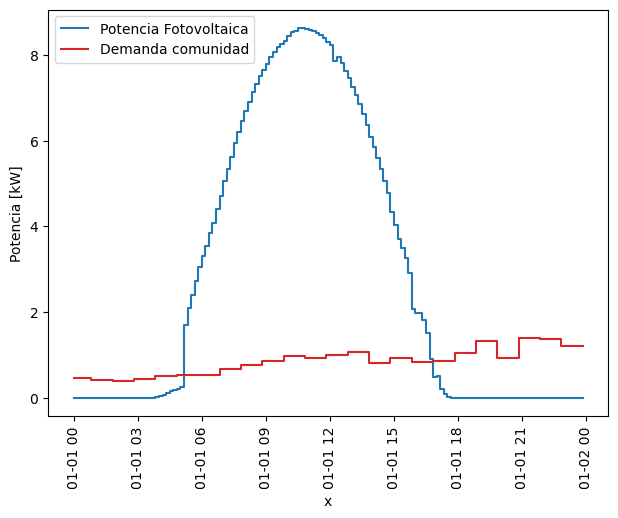

In [3]:
fig, ax = plt.subplots(dpi=100)
i = 0
# Plot the first curve and set its y label
delay = 0
color = 'tab:blue'
ax.set_xlabel('x')
ax.set_ylabel('Potencia [kW]')
ax.step(x, p_fv[timesteps*i+delay:timesteps*(i+1)+delay], color=color, label = 'Potencia Fotovoltaica')


# Create a second y-axis and plot the second curve on it
color = 'tab:red'
ax.step(x, b[timesteps*i+delay:timesteps*(i+1)+delay], color=color, label = 'Demanda comunidad')
ax.legend(loc='upper left')

fig.tight_layout()
plt.xticks(rotation=90)
plt.show()

In [4]:
path1 = 'training_results/ems/DQN_20240313_103858'
path2 = 'training_results/ems/DQN_20240313_103953'
path3 = 'training_results/ems/DQN_20240313_104048'

training_results1 = pd.read_csv(path1 + '/training_results.csv')
training_results2 = pd.read_csv(path2 + '/training_results.csv')
training_results3 = pd.read_csv(path3 + '/training_results.csv')

## Showing the results of the training

### agent 1

ValueError: x and y must have same first dimension, but have shapes (0,) and (6,)

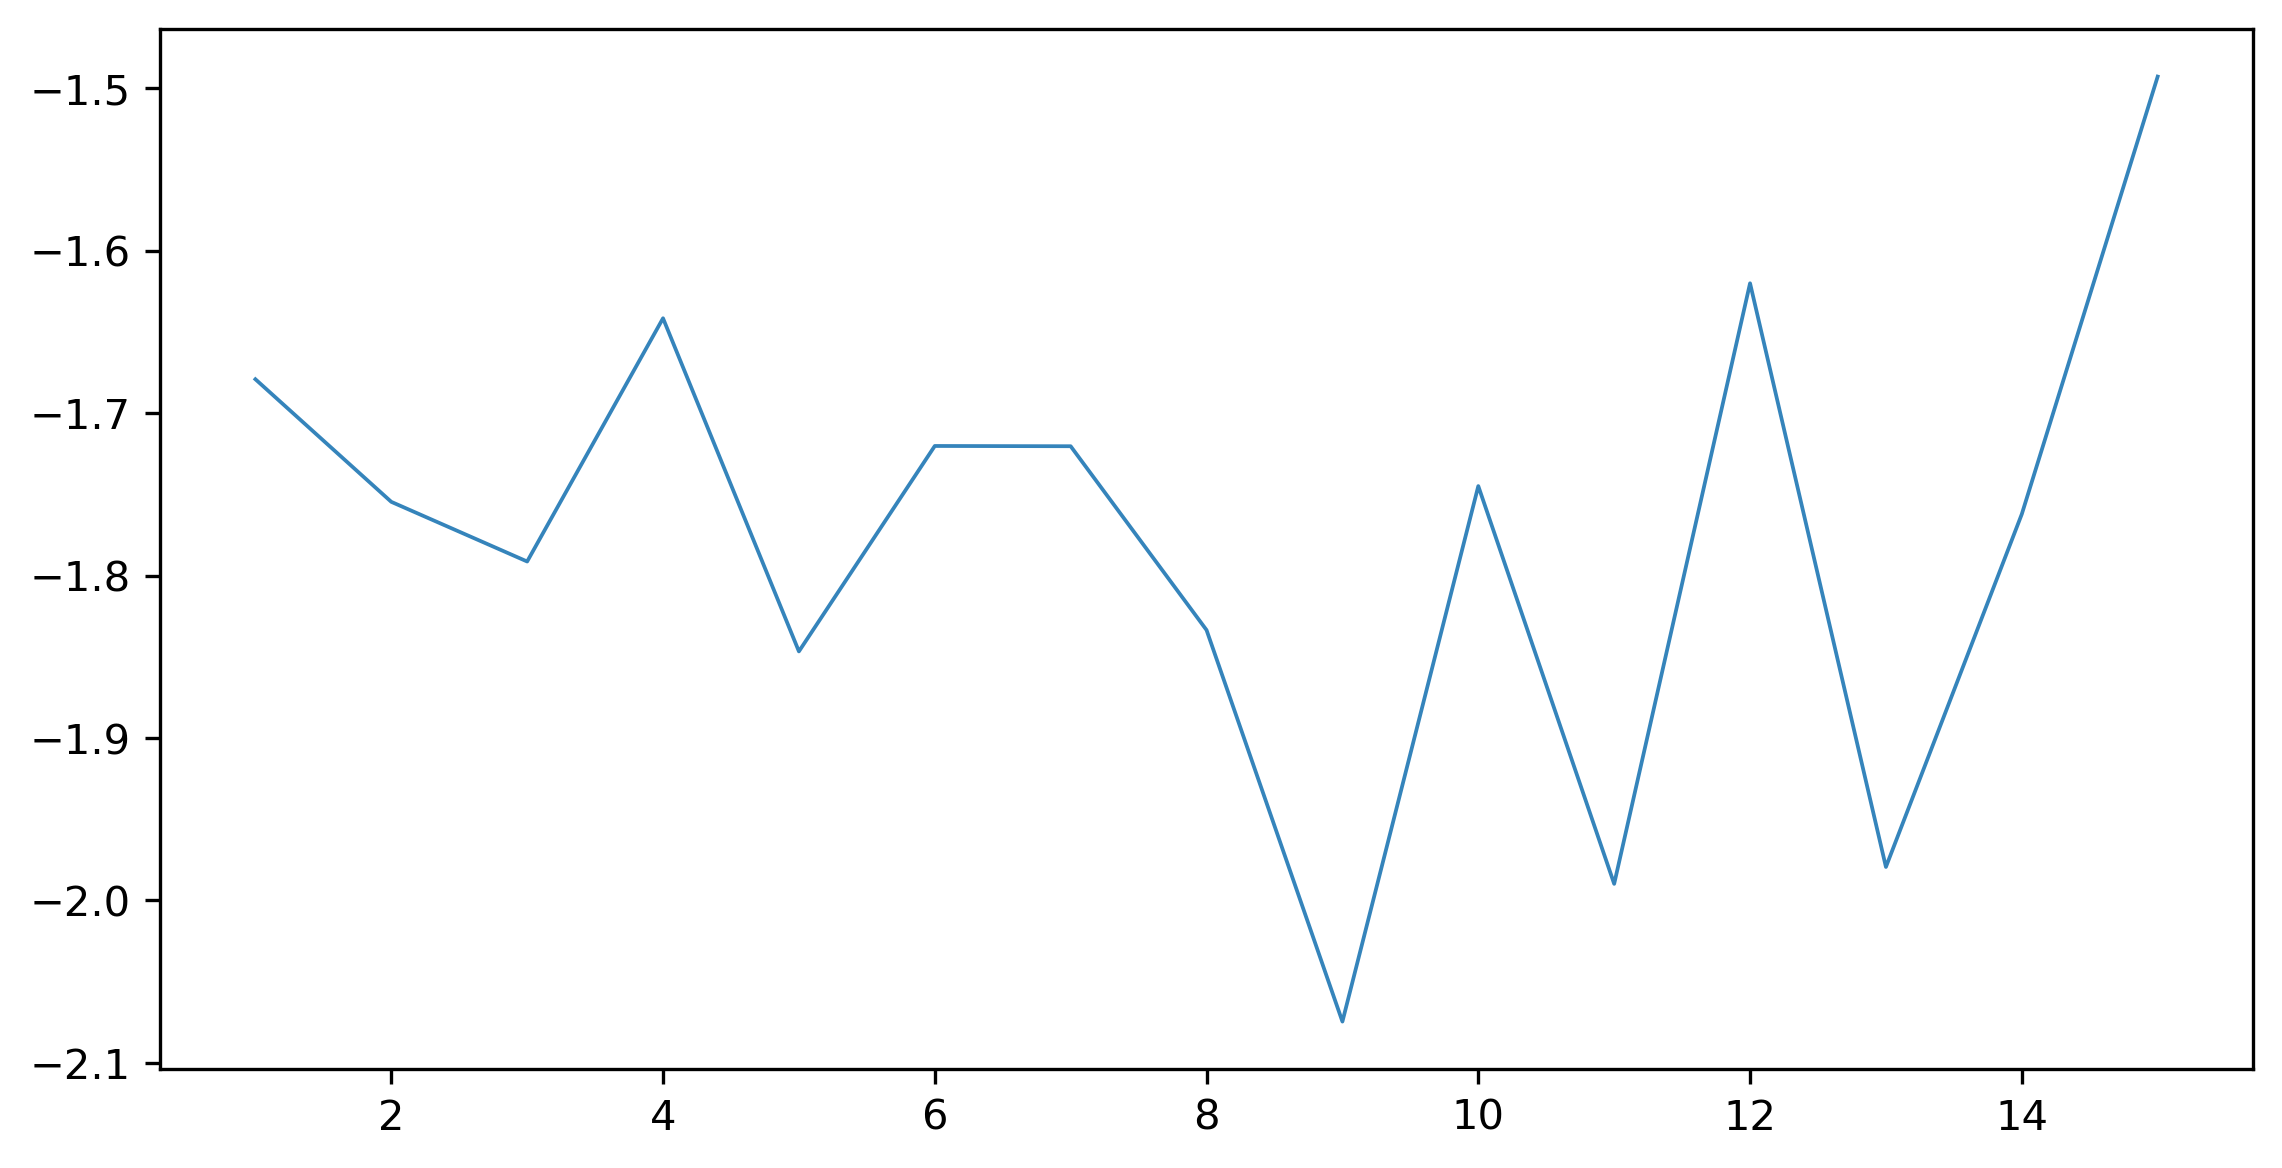

In [17]:
rwd = training_results1["mean_episode_rewards"].to_numpy()
mean_rwd = np.convolve(rwd, np.ones(20)/20, mode='valid')
N = len(rwd)
fig = plt.figure(dpi=300)
fig.set_size_inches(9.0, 4.5)
plt.plot(range(1,N+1), rwd,  label="Recompensa promedio durante el episodio", alpha=0.9, linewidth = .9)
plt.plot(range(1+19, N+1),mean_rwd, label="Promedio últimos 20 episodios", linewidth = 1)
plt.legend()
plt.xlabel("N° episodio")
plt.ylabel("Recompensa media")
plt.suptitle("Agente 1")
plt.title("Recompensa promedio por episodio durante el entrenamiento")
plt.grid()
plt.tight_layout()
plt.savefig("./figures/entrenamiento_1.png", dpi=300)

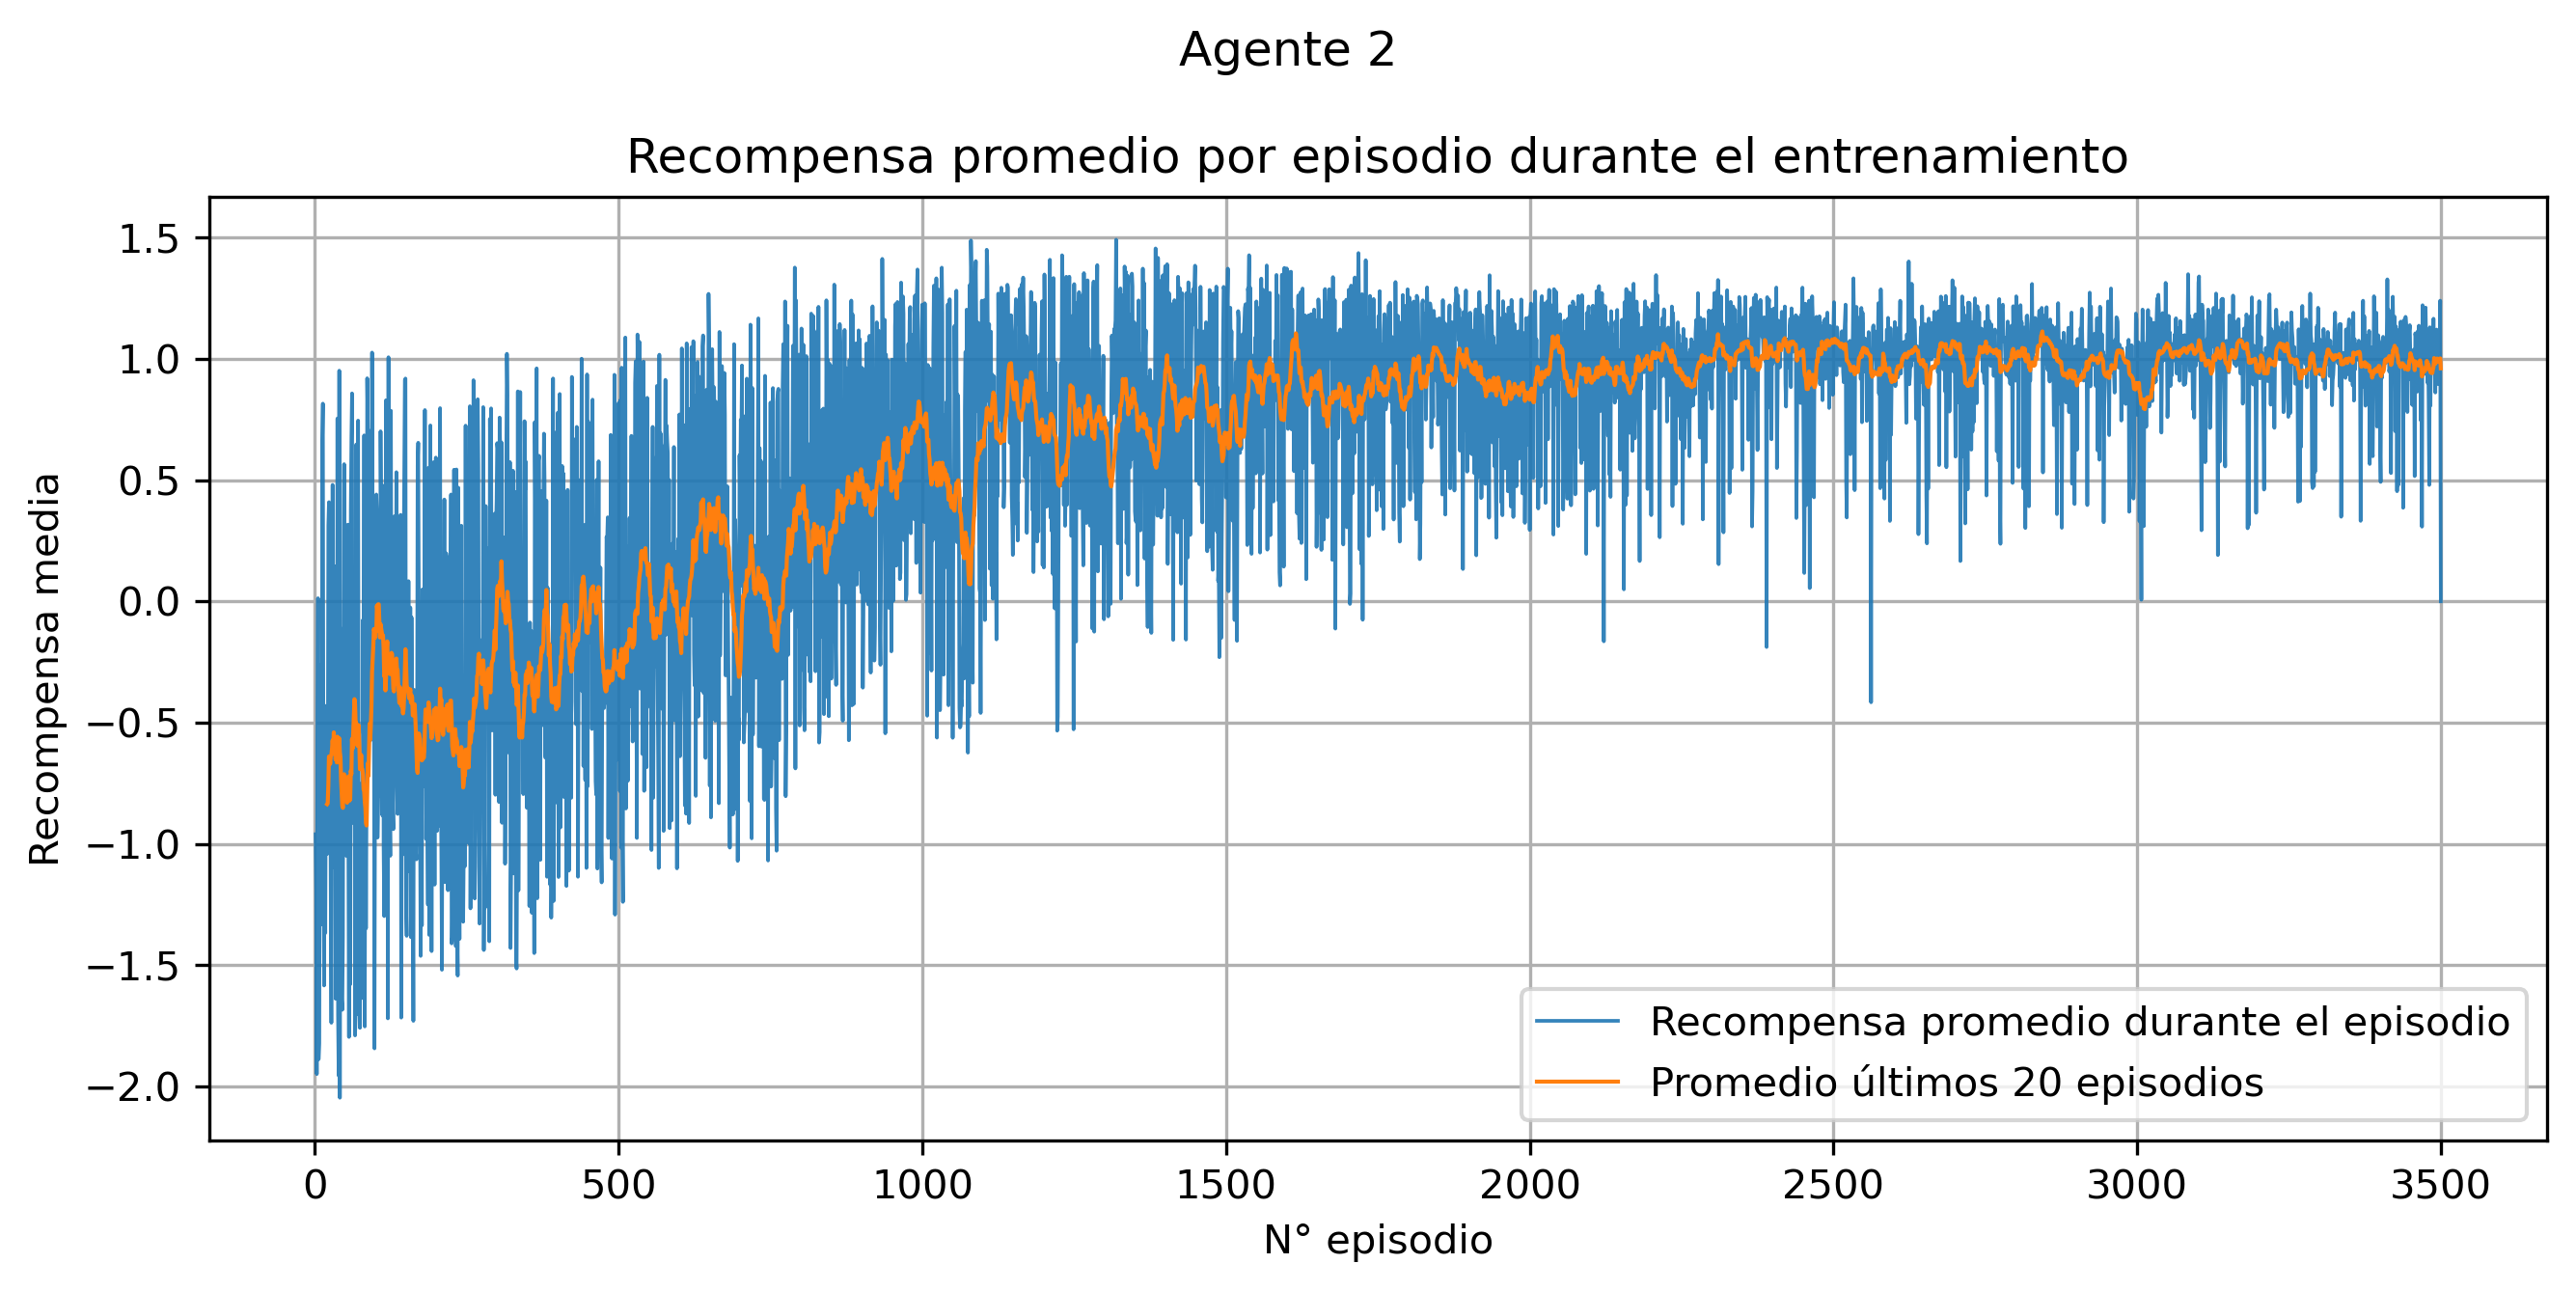

In [ ]:
rwd = training_results2["mean_episode_rewards"].to_numpy()
mean_rwd = np.convolve(rwd, np.ones(20)/20, mode='valid')
N = len(rwd)
fig = plt.figure(dpi=300)
fig.set_size_inches(9.0, 4.5)
plt.plot(range(1,N+1), rwd,  label="Recompensa promedio durante el episodio", alpha=0.9, linewidth = .9)
plt.plot(range(1+19, N+1),mean_rwd, label="Promedio últimos 20 episodios", linewidth = 1)
plt.legend()
plt.xlabel("N° episodio")
plt.ylabel("Recompensa media")
plt.suptitle("Agente 2")
plt.title("Recompensa promedio por episodio durante el entrenamiento")
plt.grid()
plt.tight_layout()
plt.savefig("./figures/entrenamiento_2.png", dpi=300)

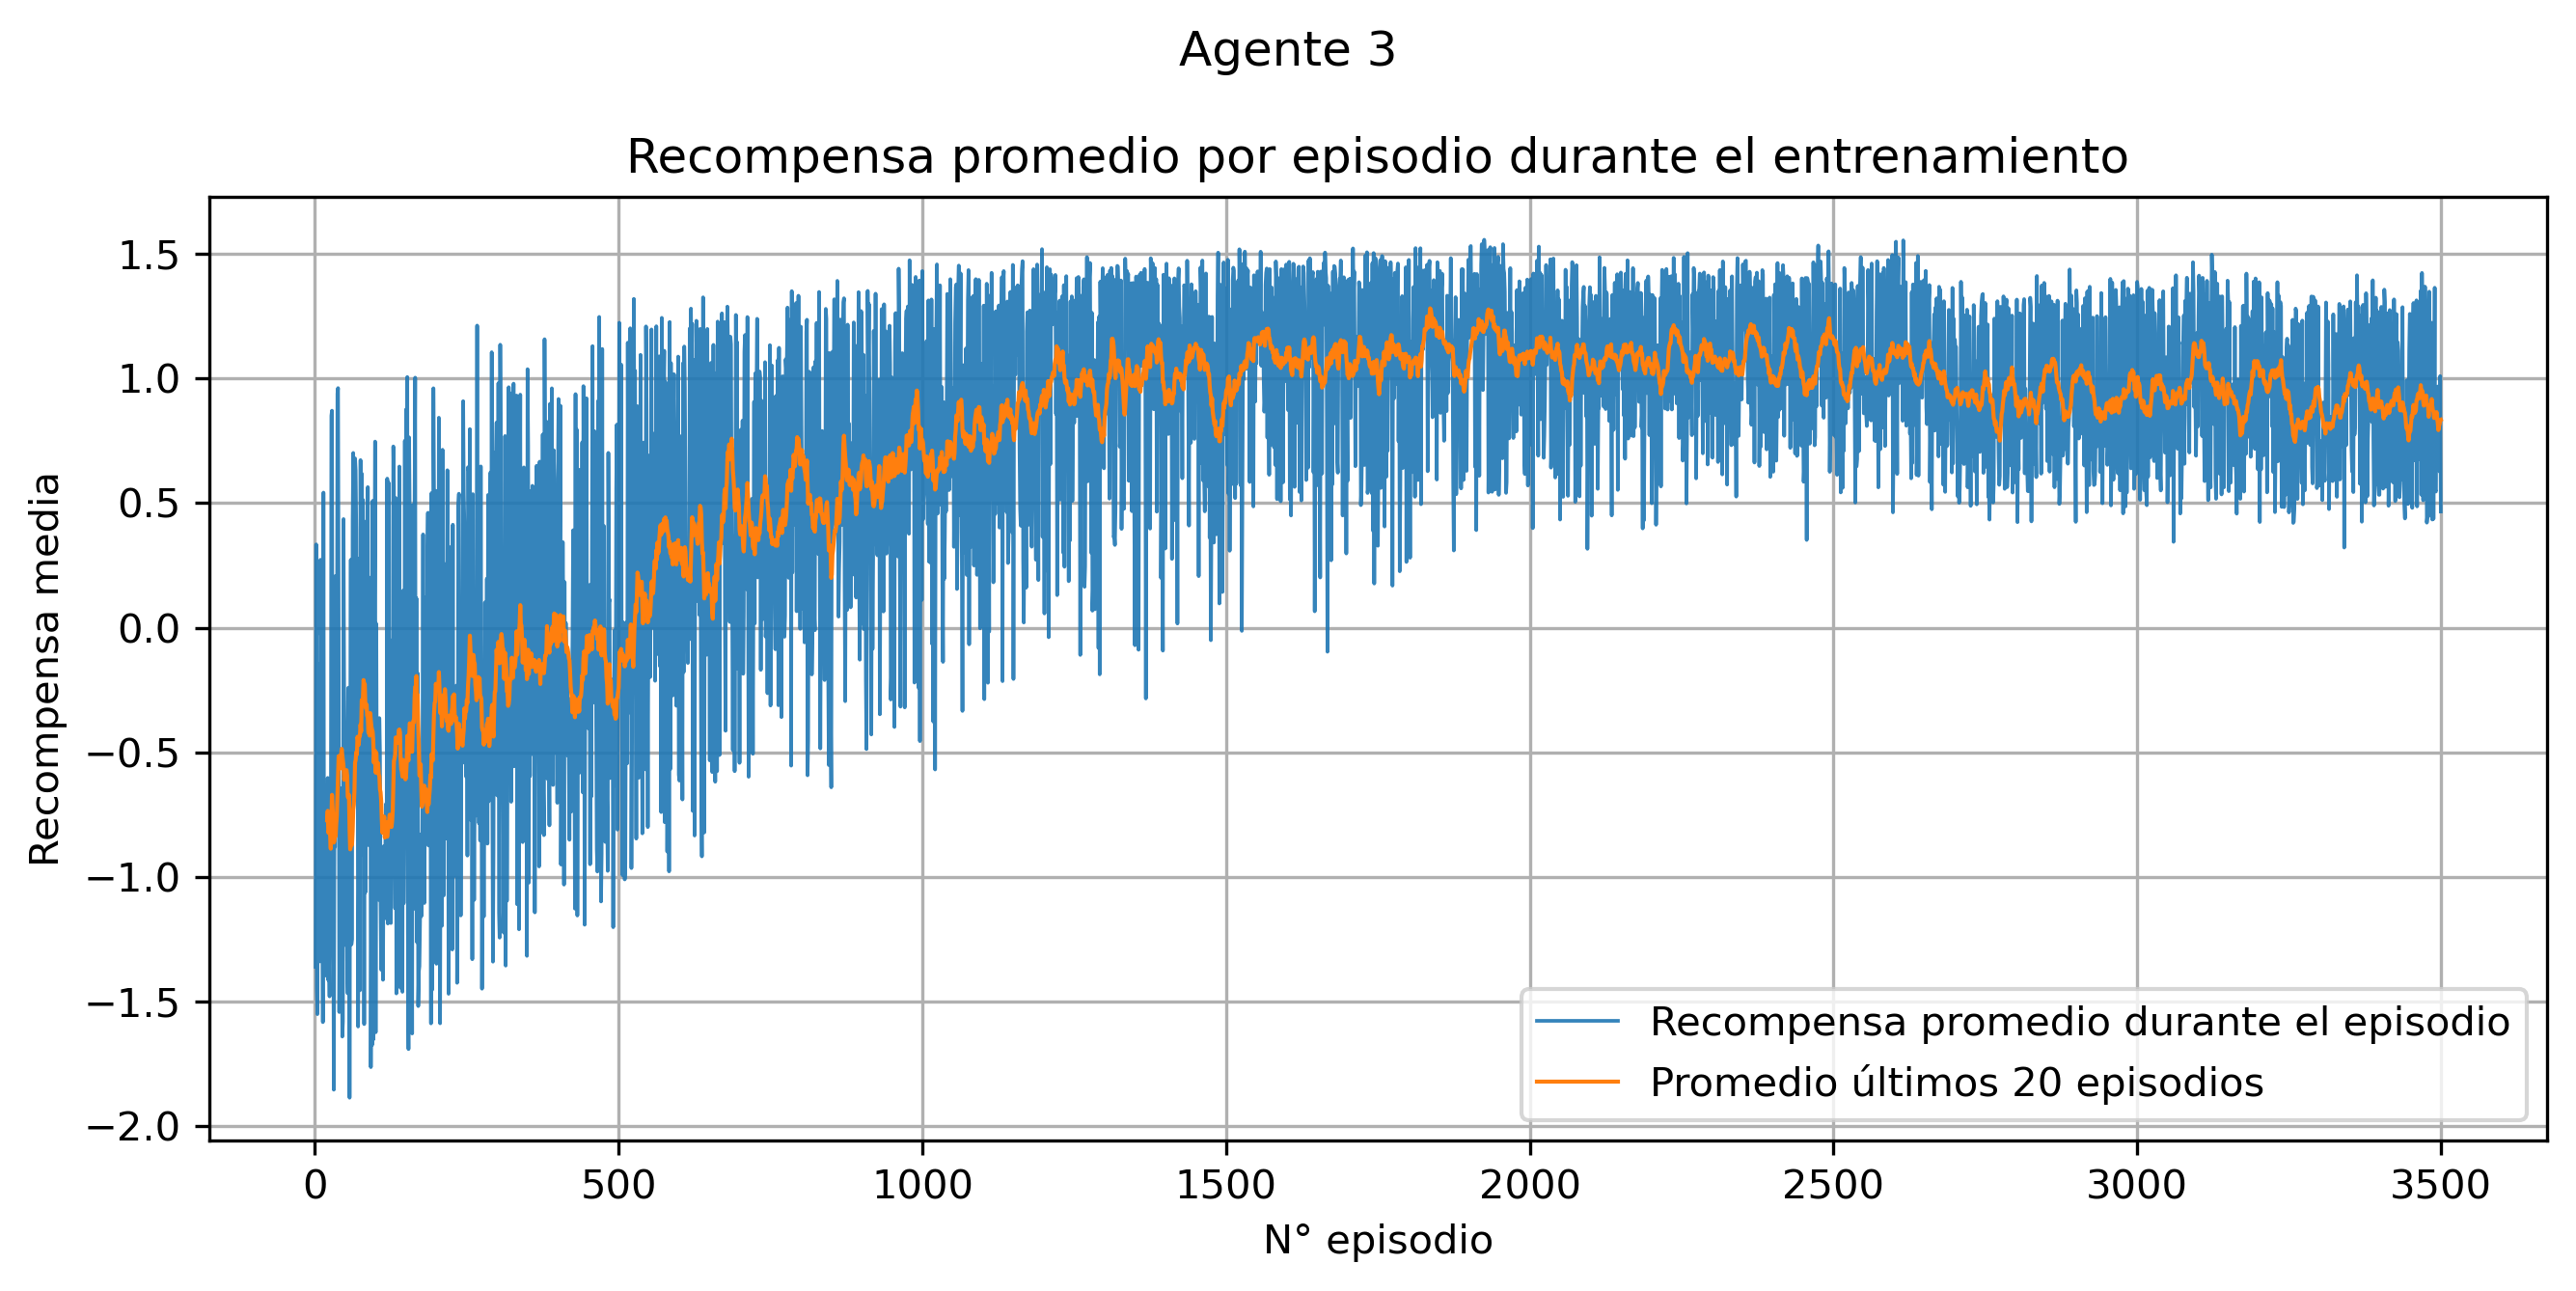

In [ ]:
rwd = training_results3["mean_episode_rewards"].to_numpy()
mean_rwd = np.convolve(rwd, np.ones(20)/20, mode='valid')
N = len(rwd)
fig = plt.figure(dpi=300)
fig.set_size_inches(9.0, 4.5)
plt.plot(range(1,N+1), rwd,  label="Recompensa promedio durante el episodio", alpha=0.9, linewidth = .9)
plt.plot(range(1+19, N+1),mean_rwd, label="Promedio últimos 20 episodios", linewidth = 1)
plt.legend()
plt.xlabel("N° episodio")
plt.ylabel("Recompensa media")
plt.suptitle("Agente 3")
plt.title("Recompensa promedio por episodio durante el entrenamiento")
plt.grid()
plt.tight_layout()
plt.savefig("./figures/entrenamiento_3.png", dpi=300)

In [5]:
def rwd_fun(s, a, s_next, e_penal=0):
    next_error = s[0] - s_next[4]
    current_error = s[0] - s[4]
    delta_error = np.abs(next_error) - np.abs(current_error)
    delta_Irr = (a[0] - s[3])/100
    delta_Q_p = (a[1] - s[5])/100

    if s[-1] != 143:
        reward = (np.exp(-1 * next_error ** 2 / (s[0] + 1e-5) ** 2 -
                  delta_Irr**2 - delta_Q_p**2) +
                  2*np.exp(-3 * next_error ** 2 / (s[0] + 1e-5) ** 2 -
                  2*delta_Irr**2 - 2*delta_Q_p**2) -
                  0.5 * np.sign(np.min([delta_error, 0])) -
                  3.0 * np.sign(np.max([delta_error, 0])))
        if s[10] != 0:
            reward = reward - e_penal
    else:
        reward = (np.exp(-1 * next_error ** 2 / (s[0] + 1e-5) ** 2 -
                  delta_Irr**2 - delta_Q_p**2) +
                  2*np.exp(-3 * next_error ** 2 / (s[0] + 1e-5) ** 2) -
                  2*delta_Irr**2 - 2*delta_Q_p**2)
        if s_next[10] != 0:
            reward = reward - e_penal

    return np.array([reward])

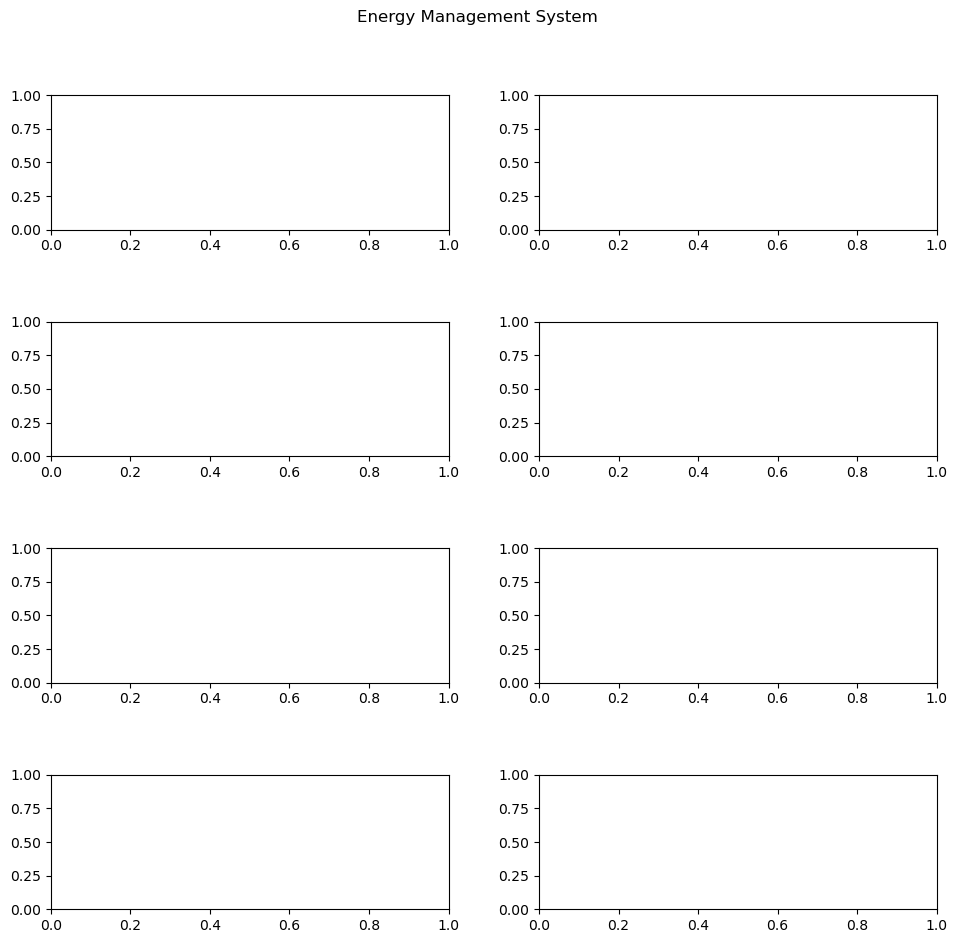

In [6]:
model1 = torch.load(path1 + '/policy.pt')
scaler1 = joblib.load(path1 + '/scaler.pkl')

model2 = torch.load(path2 + '/policy.pt')
scaler2 = joblib.load(path2 + '/scaler.pkl')

model3 = torch.load(path3 + '/policy.pt')
scaler3 = joblib.load(path3 + '/scaler.pkl')

rwd_fun_1 = lambda s, a, s_next: rwd_fun(s, a, s_next, 0)
rwd_fun_2 = lambda s, a, s_next: rwd_fun(s, a, s_next, 1)
rwd_fun_3 = lambda s, a, s_next: rwd_fun(s, a, s_next, 2)

mdl = EMS_env()
results = mdl.compare_policies([(model1, scaler1), (model2, scaler2), (model3, scaler3)], 288, [rwd_fun_1, rwd_fun_2, rwd_fun_3]) 

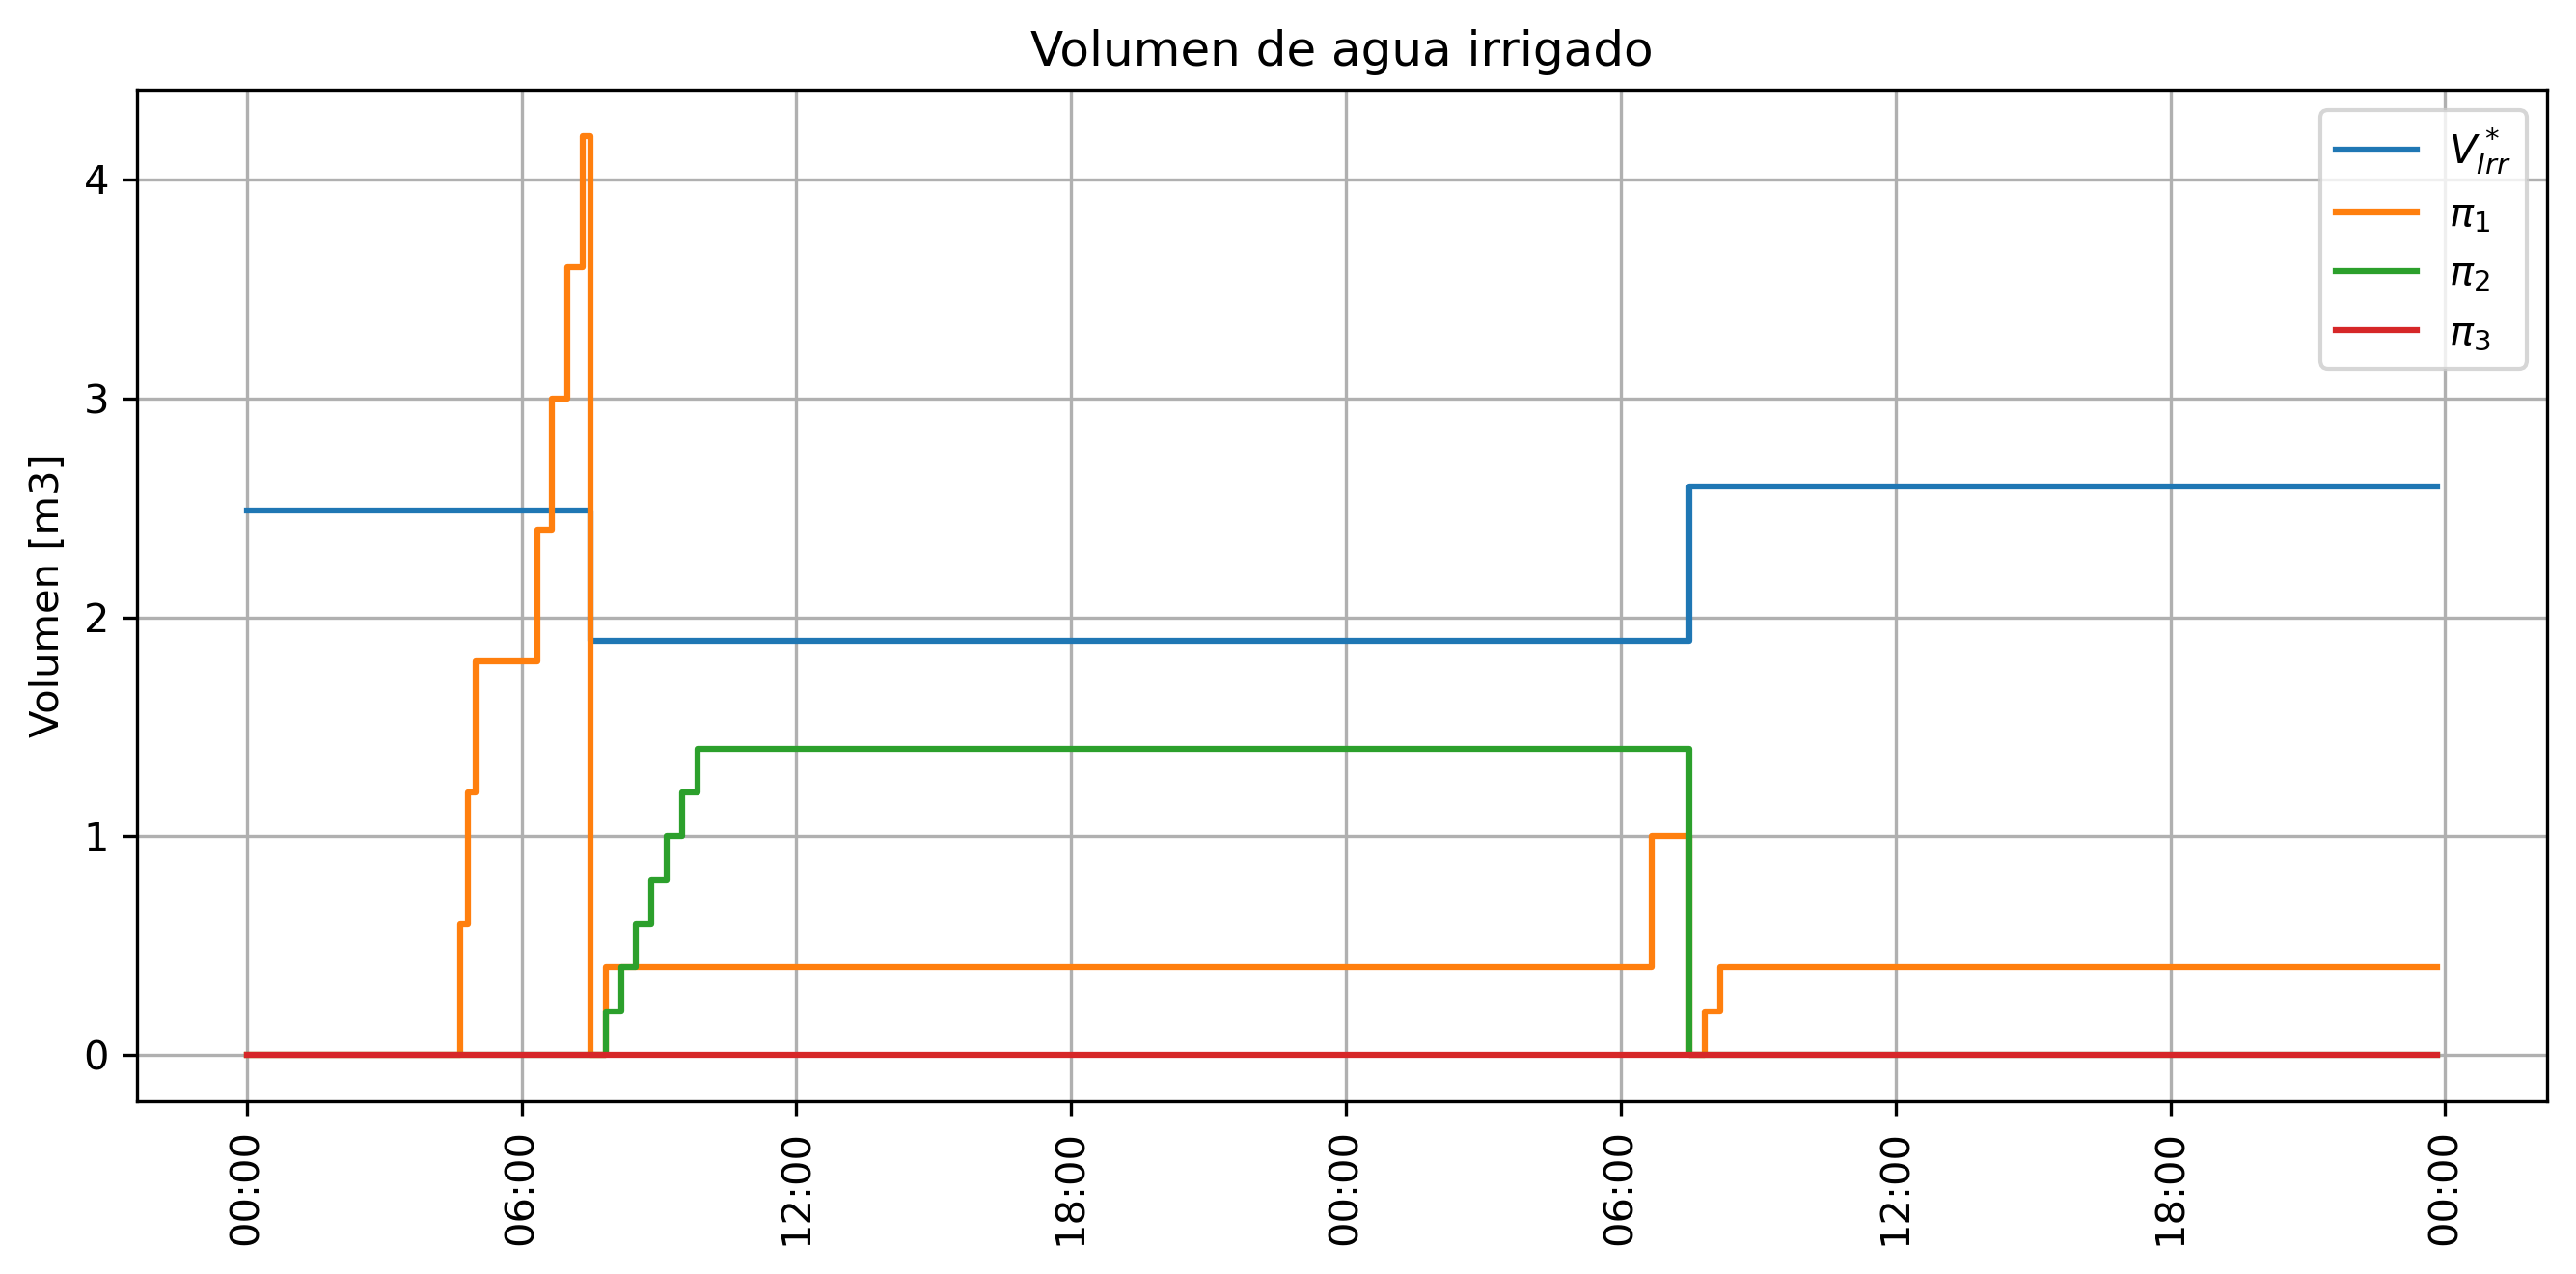

In [7]:
# Step 1: Create a list of datetime objects
start_time = datetime.datetime(2021, 1, 1, 0, 0)
time_range = [start_time + datetime.timedelta(minutes=10*i) for i in range(2*24*6)]
time_range = mdates.date2num(time_range)

fig, ax = plt.subplots(dpi=300)
fig.set_size_inches(9.0, 4.5)

ax.step(time_range, results[0][0][:-1,0], label = f"$V_{{{'Irr'}}}^*$")
for idx, result in enumerate(results):
    ax.step(time_range, result[0][:-1,4], label = f"$\pi_{idx+1}$")
plt.xticks(rotation=90)
time_format = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(time_format)
ax.set_title("Volumen de agua irrigado")
ax.set_ylabel("Volumen [m3]")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("./figures/volumen_agua_irrigado.png", dpi=300)

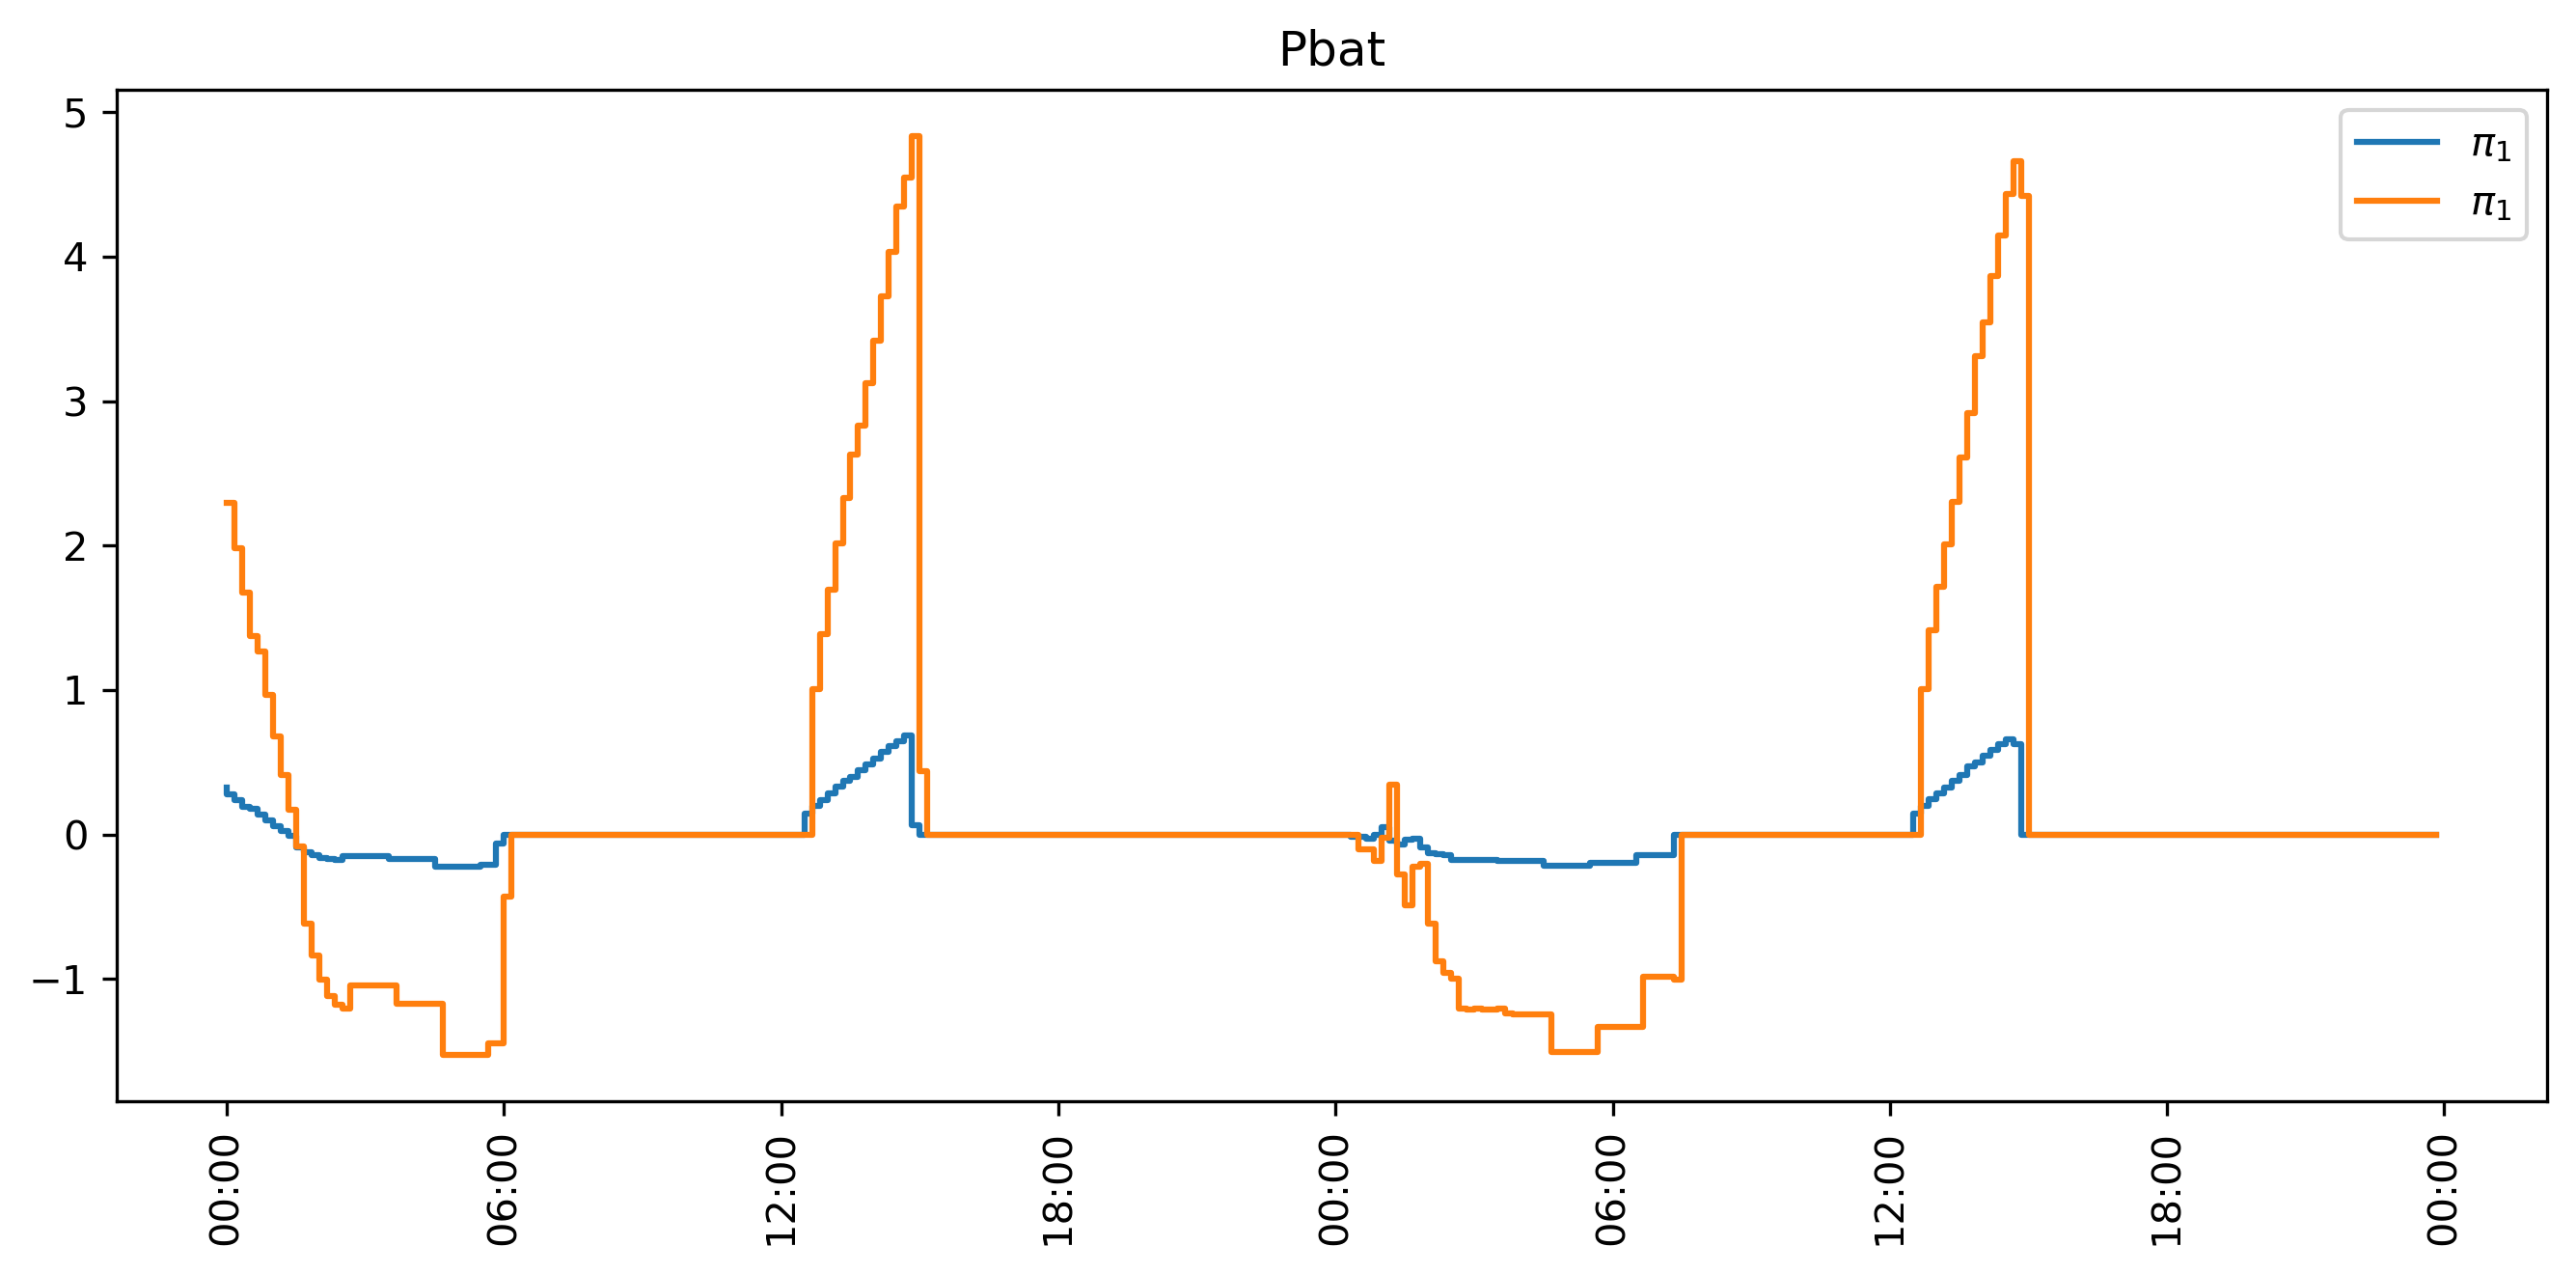

In [36]:
# Step 1: Create a list of datetime objects
start_time = datetime.datetime(2021, 1, 1, 0, 0)
time_range = [start_time + datetime.timedelta(minutes=10*i) for i in range(2*24*6)]
time_range = mdates.date2num(time_range)
fig, ax = plt.subplots(dpi=300)
fig.set_size_inches(9.0, 4.5)

for i, result in enumerate(results[0:1]):
    ax.step(time_range, np.diff(result[0][:,2]), label = f"$\pi_{i+1}$")
    ax.step(time_range, result[0][:-1,8], label = f"$\pi_{i+1}$")
plt.xticks(rotation=90)
time_format = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(time_format)
plt.title("Pbat")
plt.legend()
fig.tight_layout()

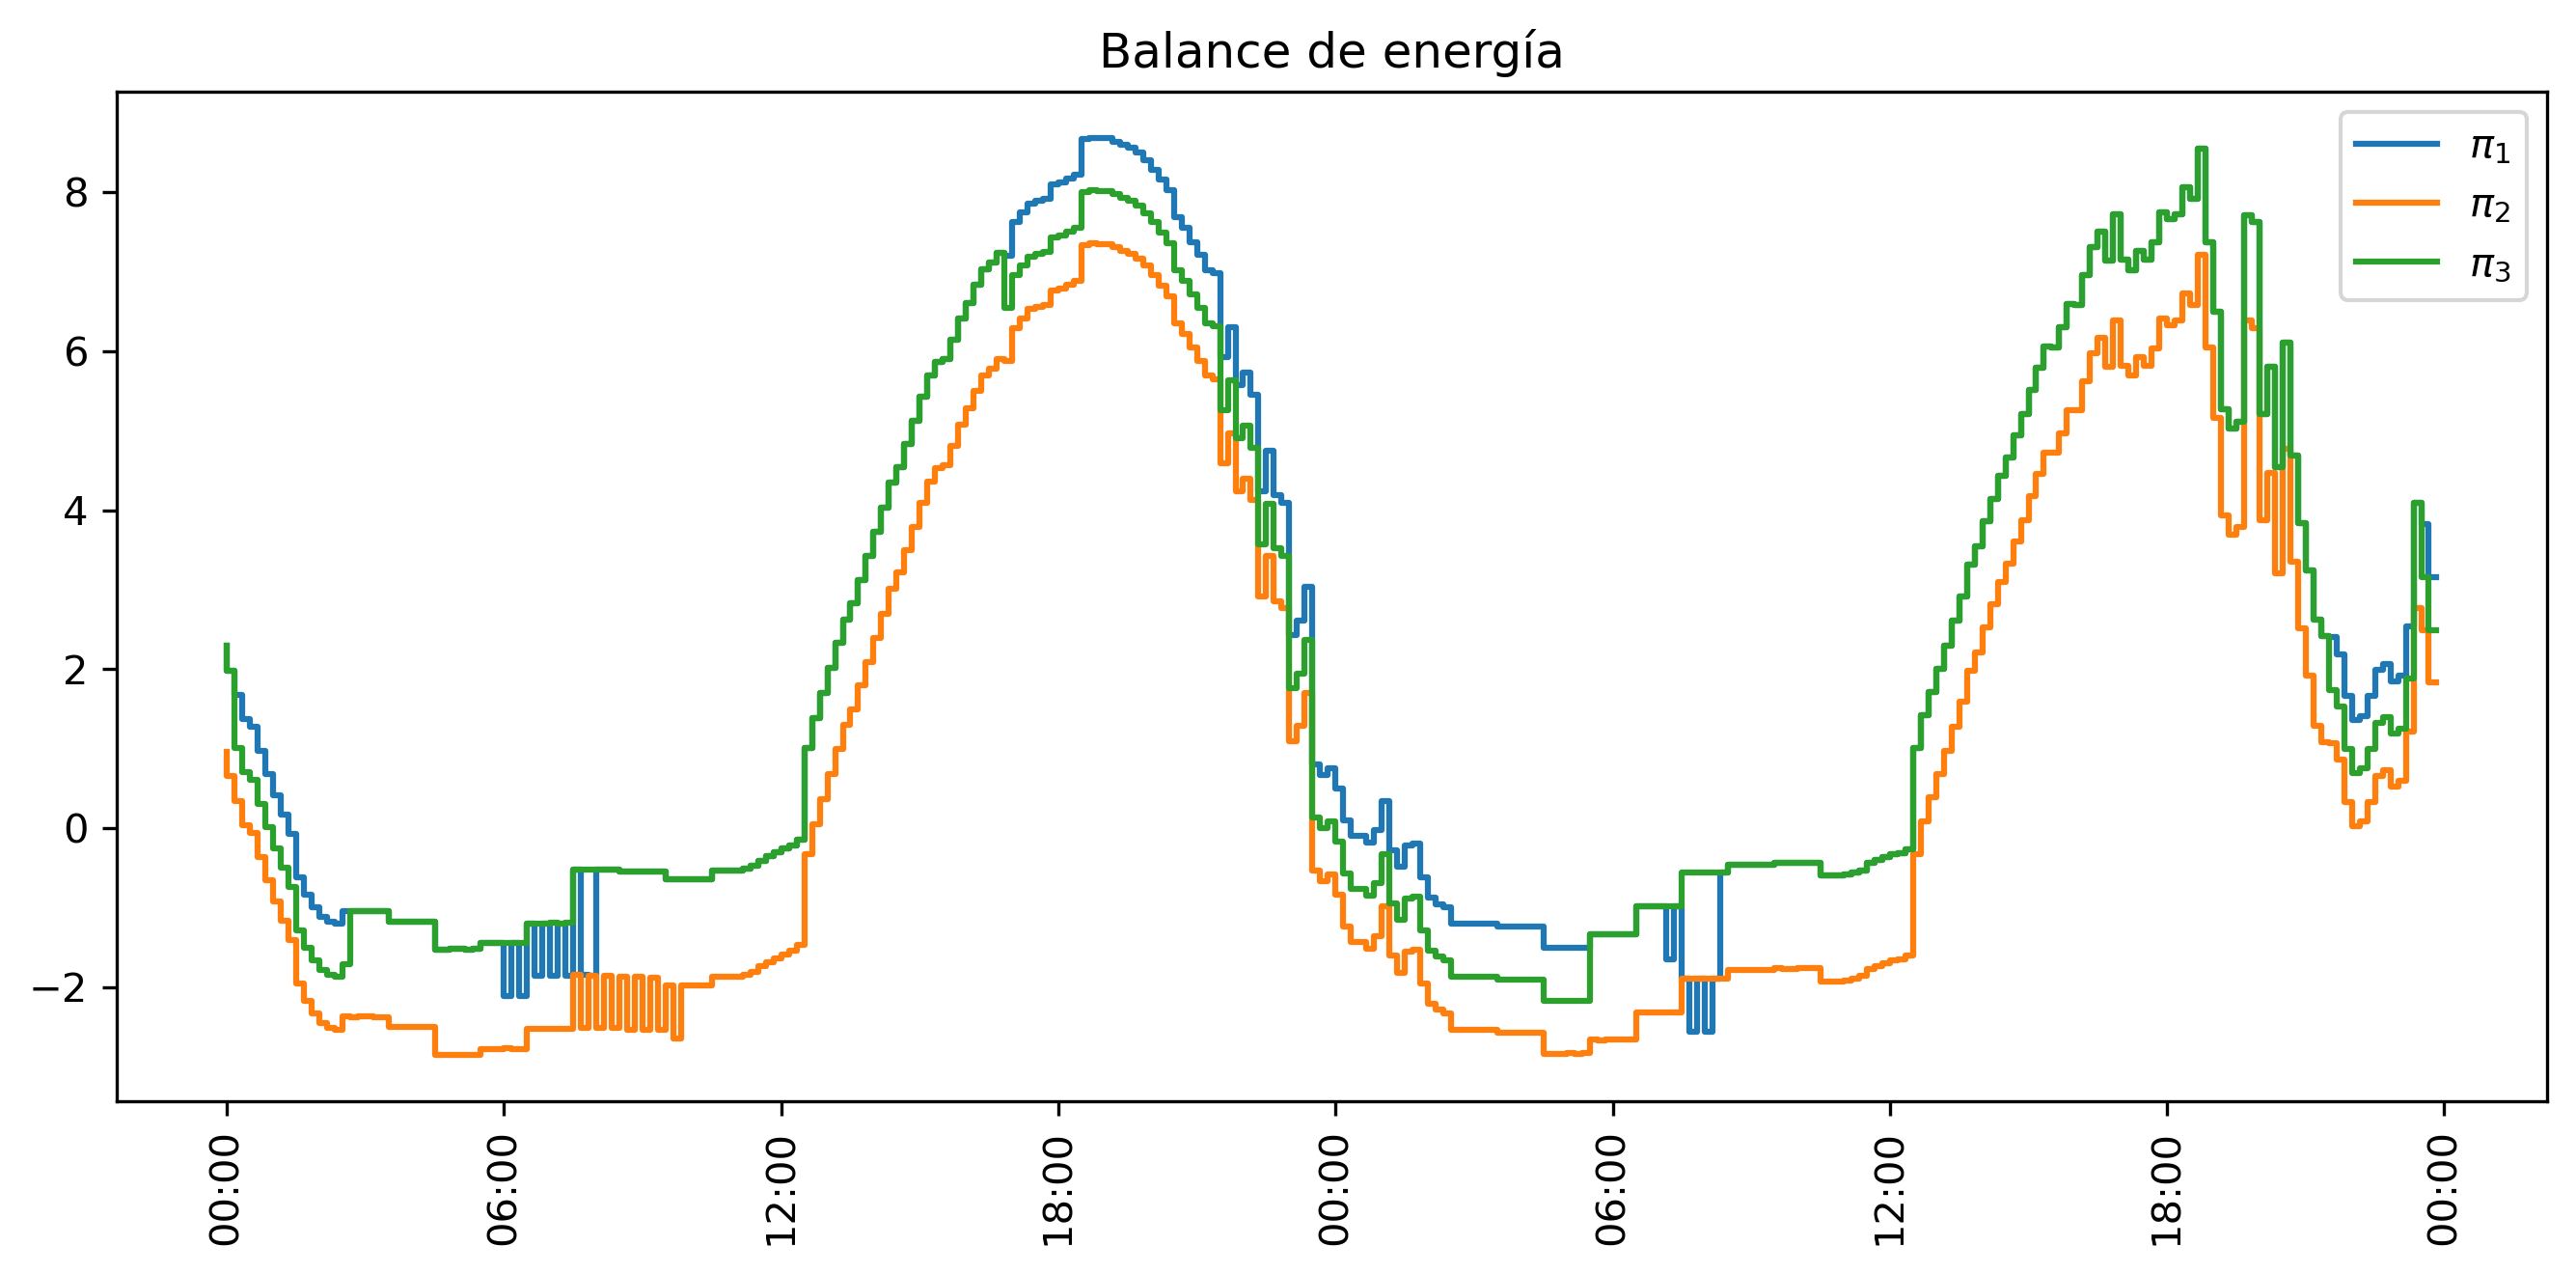

In [18]:
# Step 1: Create a list of datetime objects
start_time = datetime.datetime(2021, 1, 1, 0, 0)
time_range = [start_time + datetime.timedelta(minutes=10*i) for i in range(2*24*6)]
time_range = mdates.date2num(time_range)

fig, ax = plt.subplots(dpi=300)
fig.set_size_inches(9.0, 4.5)
for idx, result in enumerate(results):
    energy_balance = result[0][:-1,6] - result[0][:-1,7] - result[1][:,1]*20/1000
    ax.step(time_range, energy_balance, label = f"$\pi_{idx+1}$")

time_format = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(time_format)
plt.xticks(rotation=90)
plt.title("Balance de energía")
plt.legend()
fig.tight_layout()

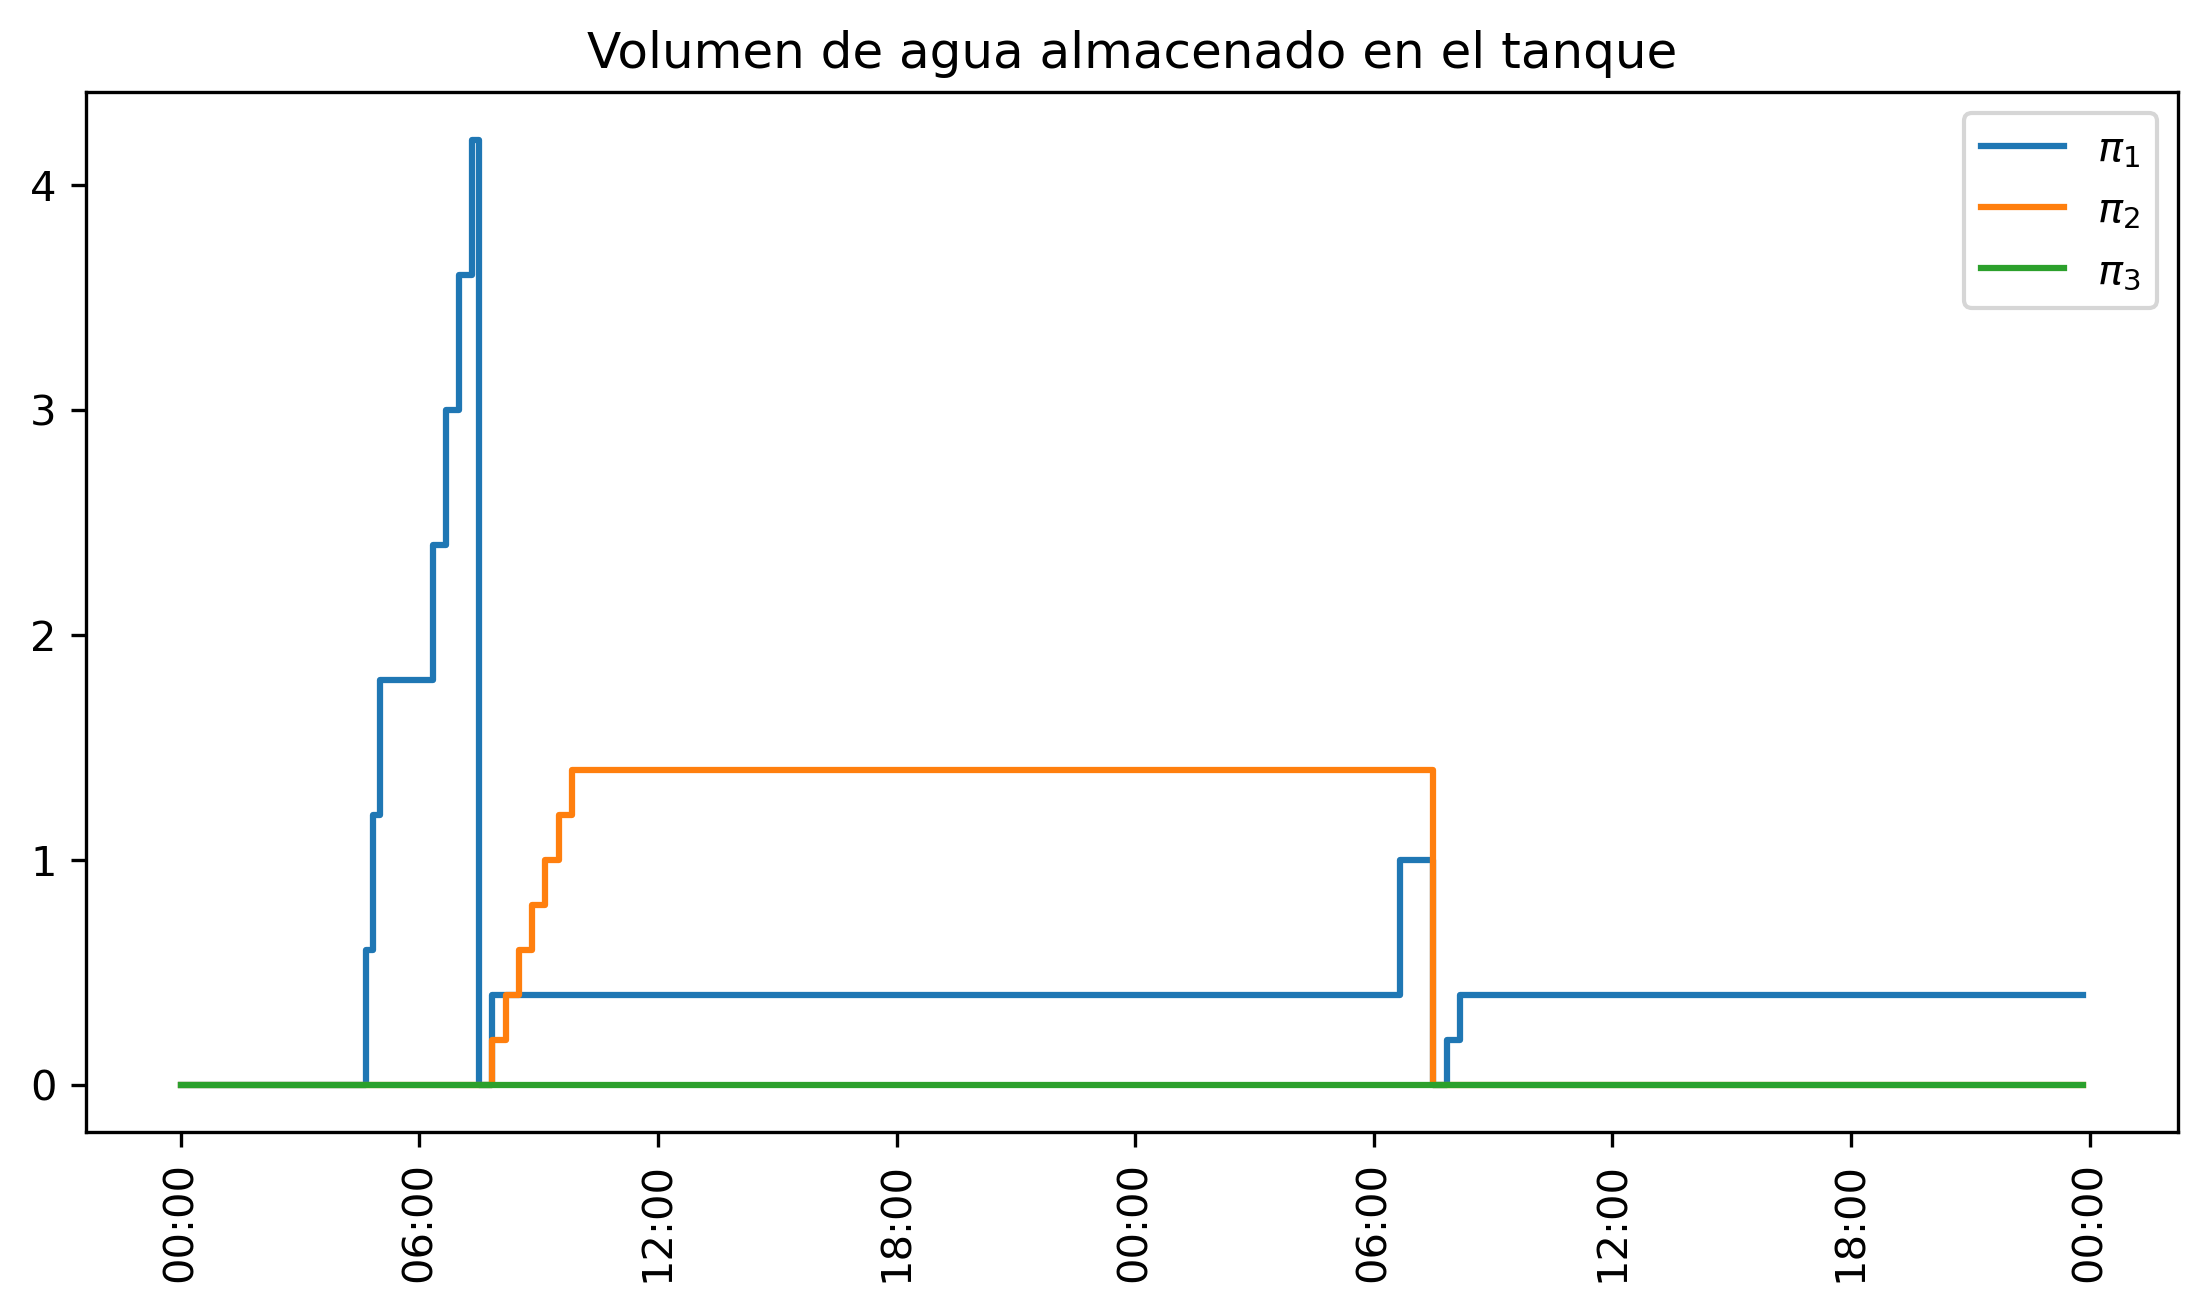

In [11]:
start_time = datetime.datetime(2021, 1, 1, 0, 0)
time_range = [start_time + datetime.timedelta(minutes=10*i) for i in range(2*24*6)]
time_range = mdates.date2num(time_range)

fig, ax = plt.subplots(dpi=300)
fig.set_size_inches(9.0, 4.5)
for idx, result in enumerate(results):
    ax.step(time_range, result[0][:-1,4], label = f"$\pi_{idx+1}$")
time_format = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(time_format)
plt.xticks(rotation=90)
plt.title("Volumen de agua almacenado en el tanque")
plt.legend()

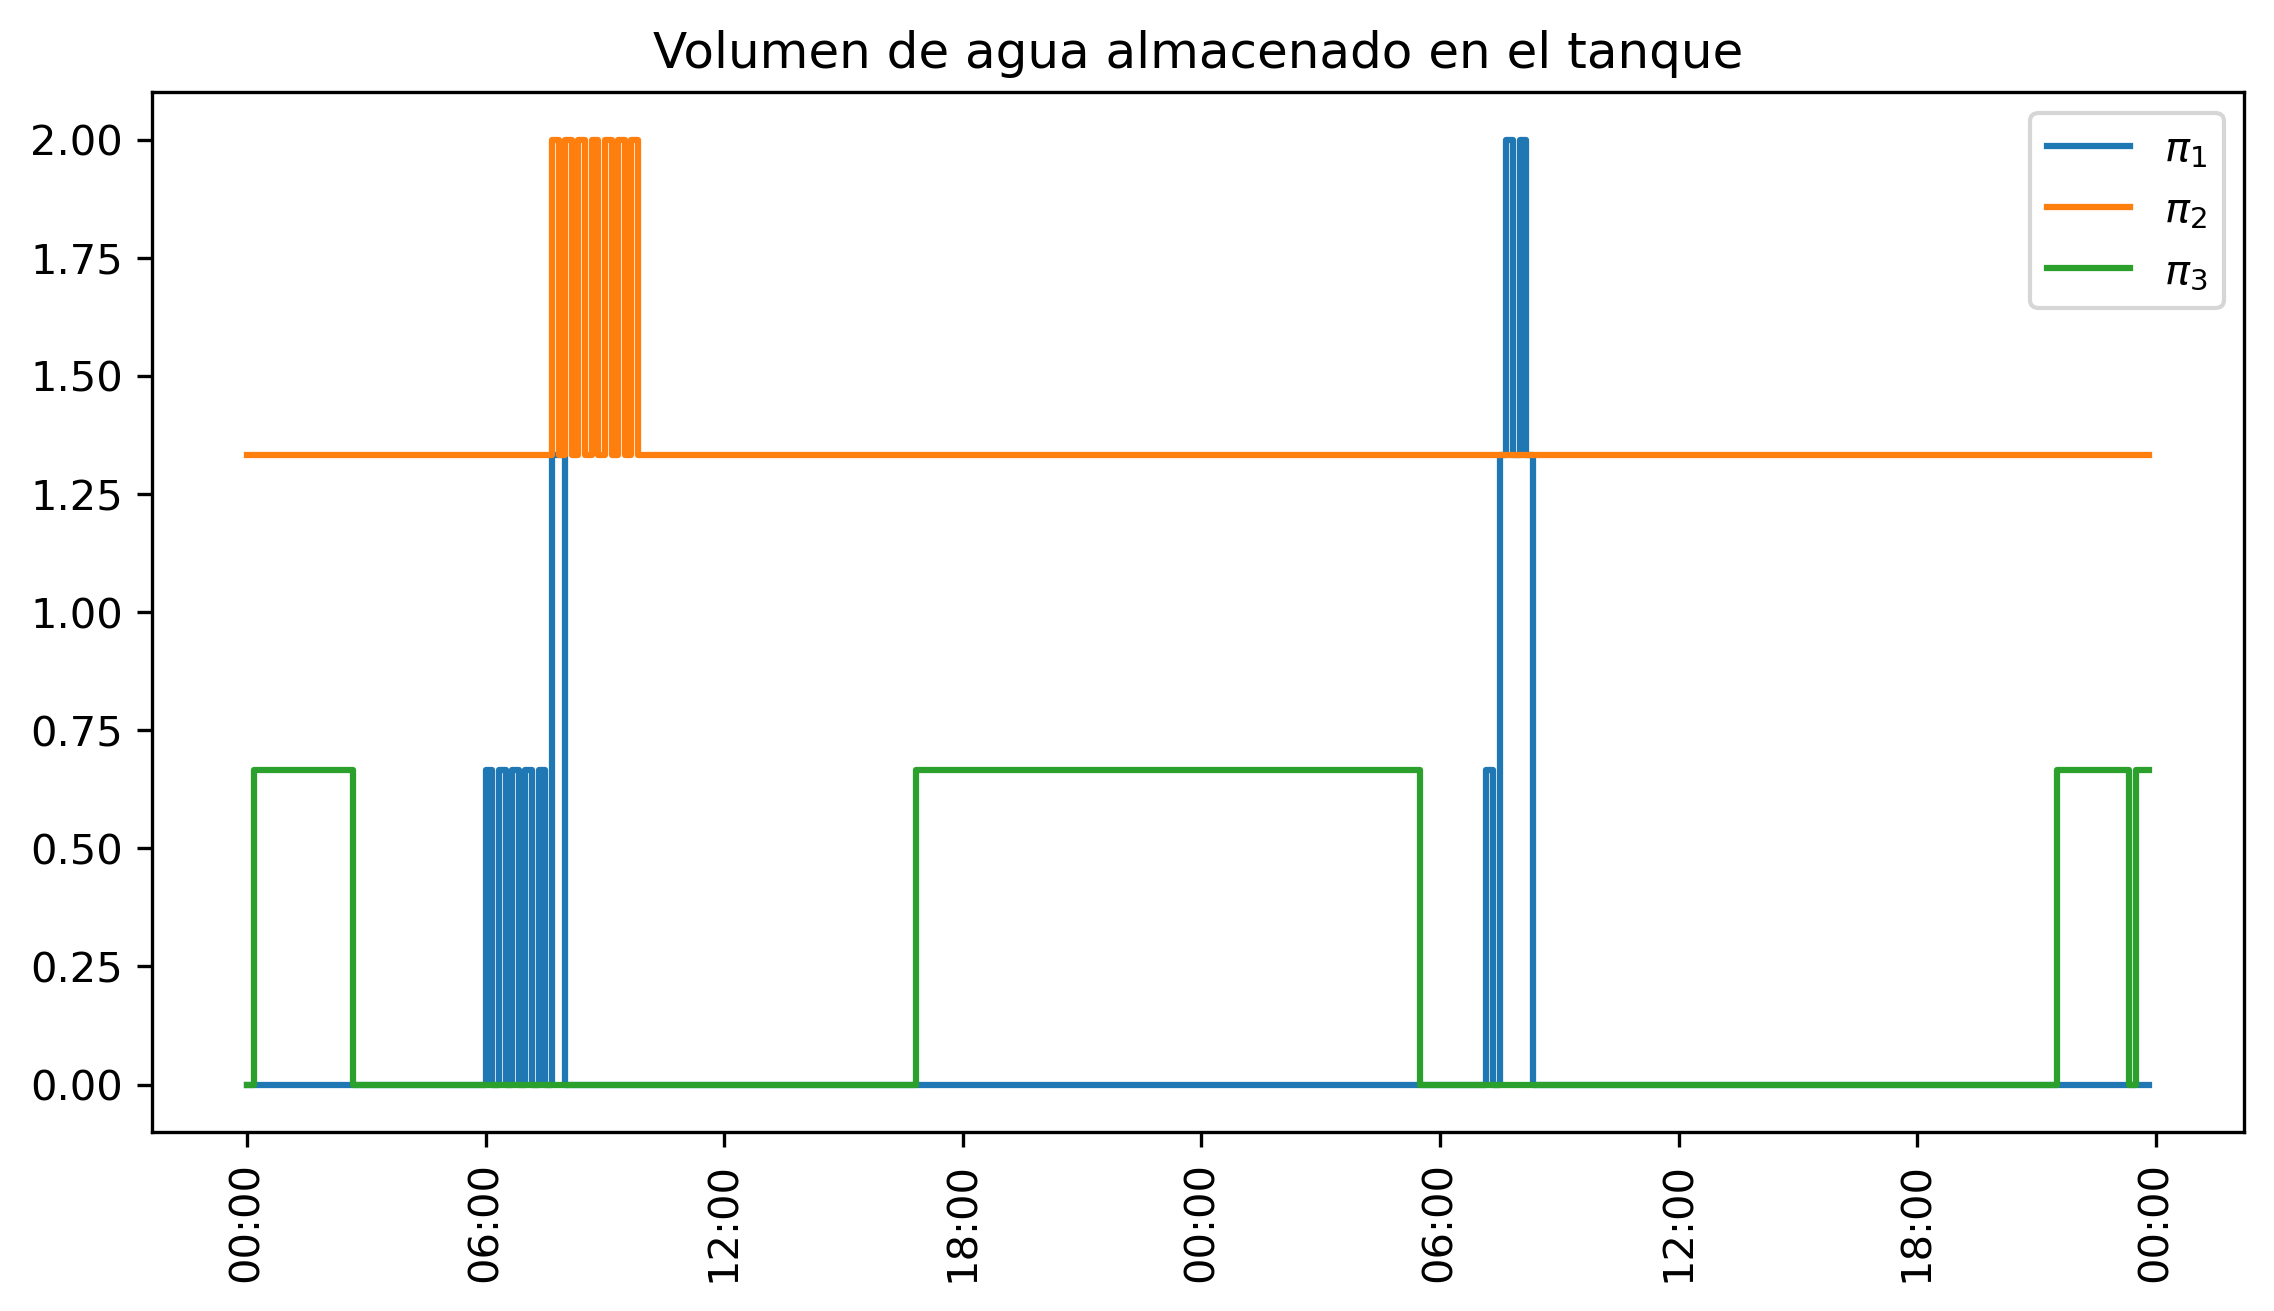

In [12]:
start_time = datetime.datetime(2021, 1, 1, 0, 0)
time_range = [start_time + datetime.timedelta(minutes=10*i) for i in range(2*24*6)]
time_range = mdates.date2num(time_range)

fig, ax = plt.subplots(dpi=300)
fig.set_size_inches(9.0, 4.5)
for idx, result in enumerate(results):
    ax.step(time_range, (result[1][:,1])*20/1000, label = f"$\pi_{idx+1}$")
time_format = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(time_format)
plt.xticks(rotation=90)
plt.title("Volumen de agua almacenado en el tanque")
plt.legend()

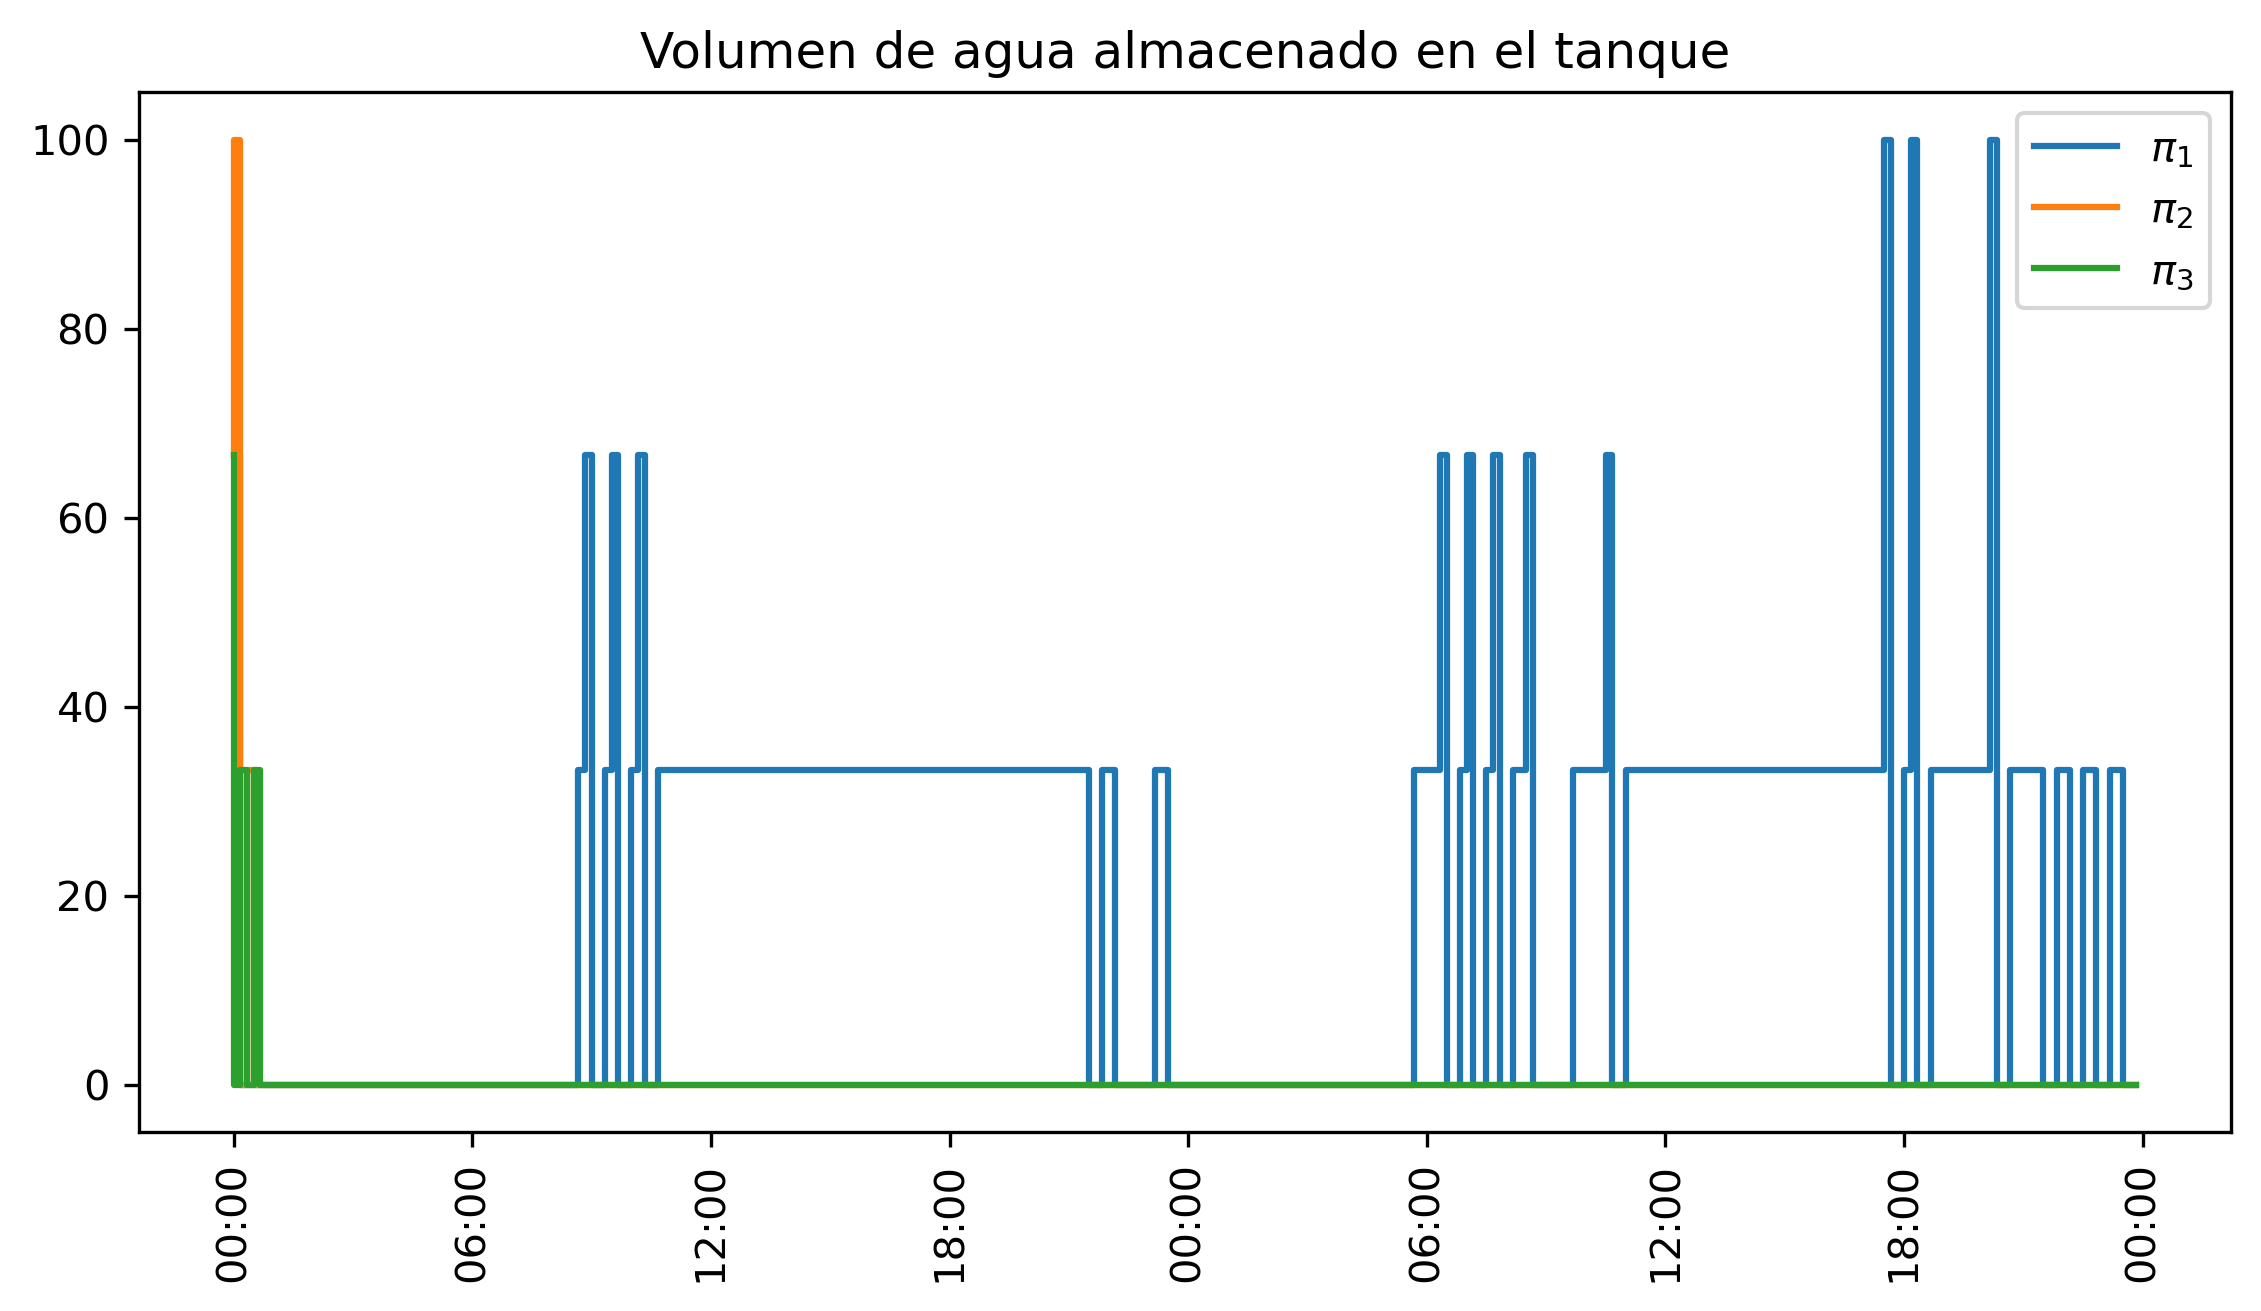

In [25]:
start_time = datetime.datetime(2021, 1, 1, 0, 0)
time_range = [start_time + datetime.timedelta(minutes=10*i) for i in range(2*24*6)]
time_range = mdates.date2num(time_range)

fig, ax = plt.subplots(dpi=300)
fig.set_size_inches(9.0, 4.5)
for idx, result in enumerate(results):
    ax.step(time_range, result[0][:-1,5], label = f"$\pi_{idx+1}$")
time_format = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(time_format)
plt.xticks(rotation=90)
plt.title("Volumen de agua almacenado en el tanque")
plt.legend()

In [ ]:
idx = 287
L = [1, 2, 3, 4, 5]
L[0:2]

[1, 2]

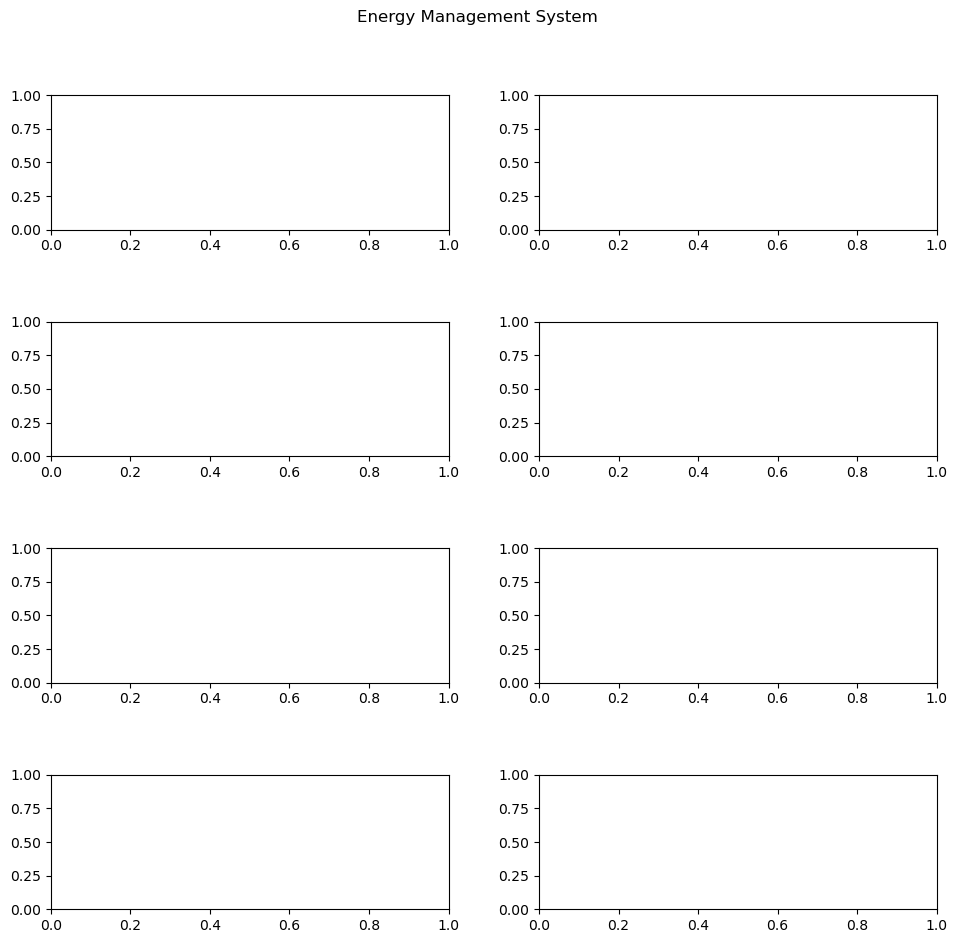

In [ ]:
### compare the results of the policies  

N = 200 # number of executions  

errors = np.zeros((3, 2*N))
average_deficit = np.zeros_like(errors)
env = EMS_env()
for model_idx, policy in enumerate([model1, model2, model3]):
    for i in range(N):
        states, actions, rews = env.sample_trajectory(policy, None, 288)
        average_deficit[model_idx,i:i+2] = np.array([np.sum(states[:144, 10]), np.sum(states[144:, 10])])
        errors[model_idx,i:i+2] = np.array([states[143, 0] - states[143, 4], states[287, 0] - states[287, 4]])


In [ ]:
errors[0]

array([ 0.93472755,  0.79511578,  1.78758982,  0.21355368,  1.10647911,
        1.16739327,  0.07567652,  2.09617429,  1.13813491,  0.86004523,
        0.85470443,  1.10647312,  0.74602508, -0.04867262,  1.44895901,
       -0.12      ,  0.66285008,  0.83470643,  0.21188205,  0.0044791 ,
        2.11617829,  1.36738528,  1.12644713,  0.21355368,  1.69542041,
        0.77963109,  1.6038529 ,  0.2418556 ,  0.77963109,  1.77381351,
        0.21625851,  1.78786178,  1.72672687,  0.20618297,  1.2342299 ,
        0.46886273,  1.3592108 ,  1.1067562 ,  1.35919881,  0.65652386,
        0.70915879, -0.04867262,  0.93697654,  1.78759582,  0.72284409,
        0.23941313,  0.89838559,  0.79245426,  1.19426388,  0.31989474,
        1.4868346 ,  0.37633923,  0.75106132,  0.95837959,  1.83381351,
        0.92431719,  1.34738727,  0.71651786,  0.54885473,  1.3592108 ,
        0.57662156,  0.33633723,  1.73377553,  0.75511977,  0.21625851,
        0.96203112,  0.66365139,  0.13567652,  0.87838759,  0.74

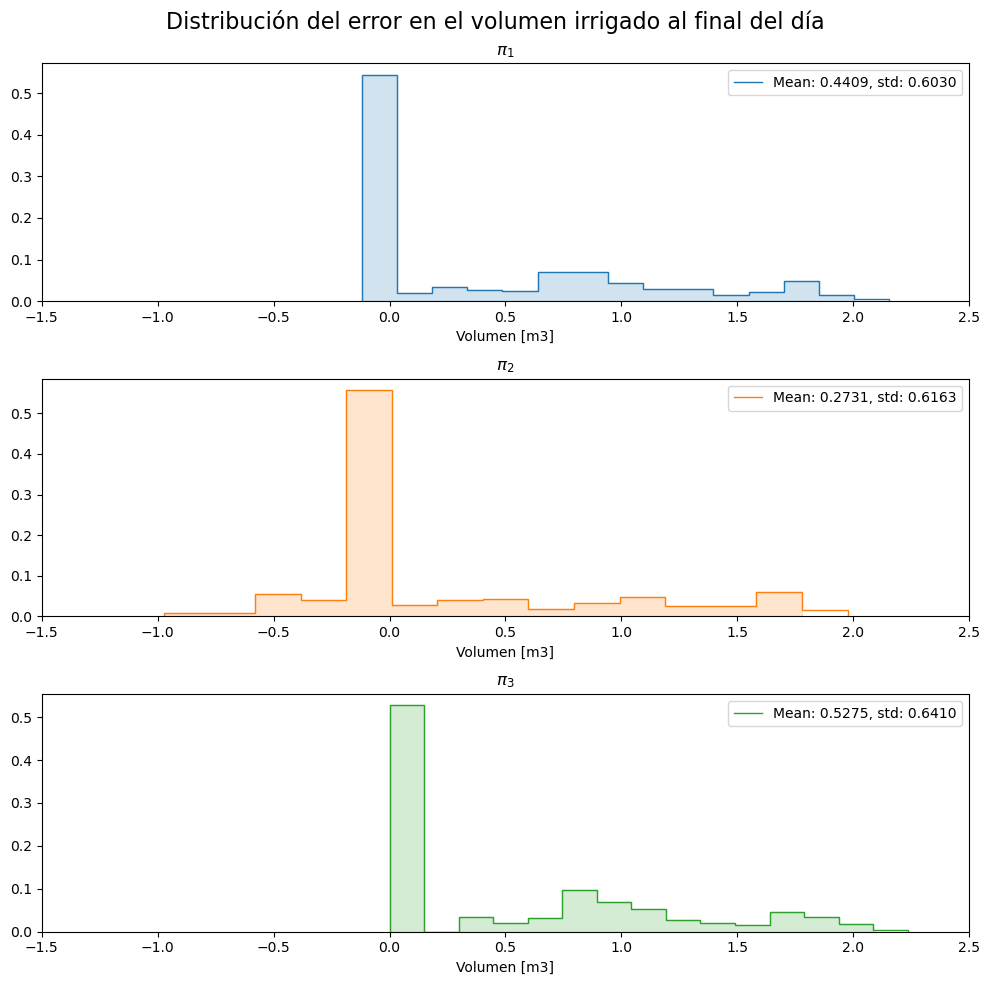

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10))
colors = ['tab:blue', 'tab:orange', 'tab:green']

for idx, ax in enumerate(axs):
    ax.set_xlim(-1.5, 2.5)
    counts, bins = np.histogram(errors[idx], bins=15)
    ax.stairs(counts/400, 
              bins, 
              label = f"Mean: {np.mean(errors[idx]):.4f}, std: {np.std(errors[idx]):.4f}", 
              color=colors[idx])
    ax.fill_between(bins[:-1], counts/400, alpha=0.2, color=colors[idx], step='post')
    ax.legend()
    ax.set_title(f"$\pi_{idx+1}$")
    ax.set_xlabel("Volumen [m3]")

fig.suptitle('Distribución del error en el volumen irrigado al final del día', fontsize=16)
fig.tight_layout()
fig.savefig("./figures/volumen agua.png", dpi=300)

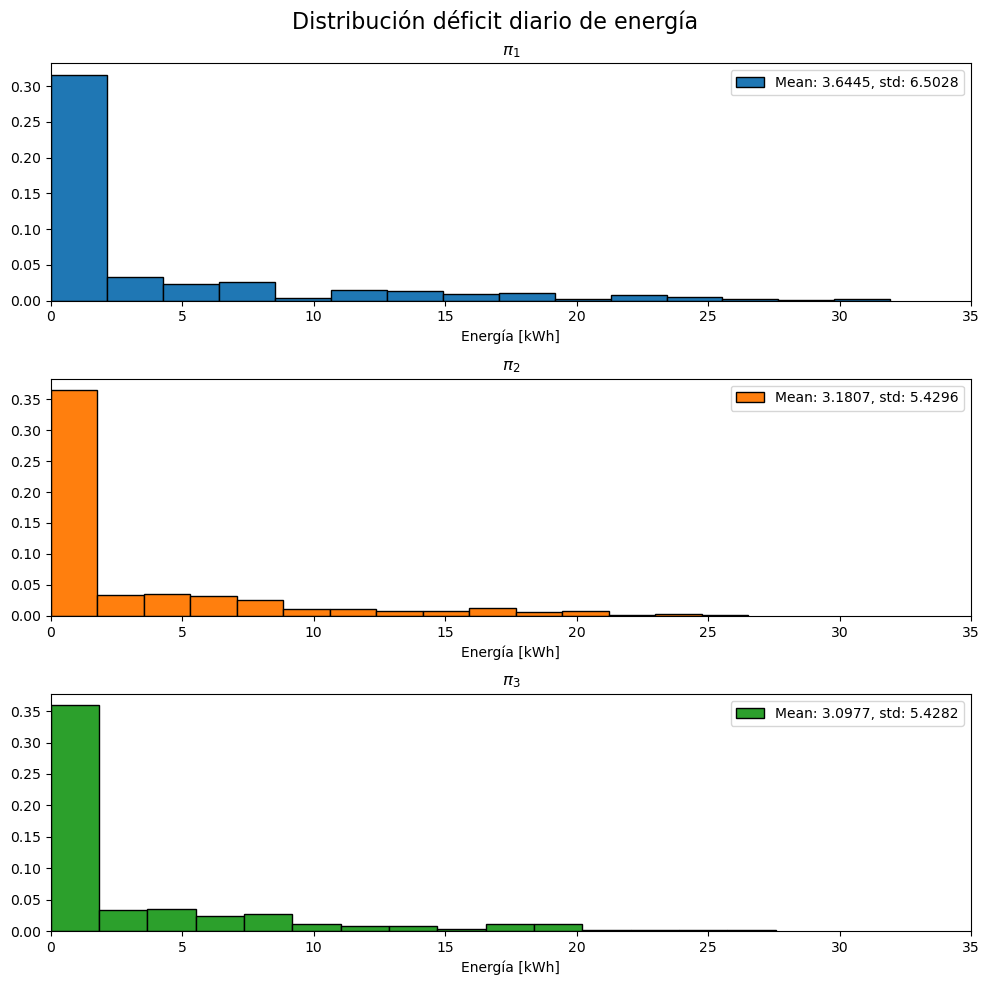

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(10, 10))

colors = ['tab:blue', 'tab:orange', 'tab:green']

for idx, ax in enumerate(axs):
    ax.set_xlim(0, 35)
    ax.hist(-average_deficit[idx], bins=15, edgecolor='black', 
            label = f"Mean: {np.mean(-average_deficit[idx]):.4f}, std: {np.std(-average_deficit[idx]):.4f}", 
            color=colors[idx], 
            density = True, 
            stacked = True)
    ax.legend()
    ax.set_title(f"$\pi_{idx+1}$")
    ax.set_xlabel("Energía [kWh]")
    
fig.suptitle('Distribución déficit diario de energía', fontsize=16)
fig.tight_layout()
fig.savefig("./figures/deficit_energia.png", dpi=300)

In [ ]:
average_deficit[2]


-0.16718916514147114